# Dynamics of conformal metamaterials


## Imports


In [2]:
import os
import cv2
from matplotlib.collections import PatchCollection
from blockymetamaterials.dynamics import build_reaction_force
from blockymetamaterials.plotting import generate_animation, generate_mode_images
from blockymetamaterials.utils import SolutionType, SolutionData, EigenmodeData, ControlParams, GeometricalParams, LigamentParams, MechanicalParams, ContactParams, save_data, load_data
from blockymetamaterials.geometry import RotatedSquareGeometry, rotation_matrix
from blockymetamaterials.energy import build_strain_energy, ligament_energy, ligament_energy_linearized, build_contact_energy, combine_block_energies
from blockymetamaterials.dynamics import setup_dynamic_solver, linear_mode_analysis
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib.colors as colors
from pathlib import Path
import dataclasses
from dataclasses import dataclass
from typing import Any, Literal, Optional, List, Union, Tuple
import numpy as np
import pickle
import math
import matplotlib
from matplotlib import cm
import jax
import shutil
from PIL import Image

from blockymetamaterials.geometry import current_coordinates


import jax.numpy as jnp
from jax import grad, jit, vmap, pmap
from jax.config import config
config.update("jax_enable_x64", True)  # enable float64 type
# config.update("jax_log_compiles", 1)
import nlopt
plt.style.use(["science", "grid"])
%matplotlib widget

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


## Problem definition


In [3]:
@dataclass
class ForwardProblem:
    """
    Forward problem for harmonically excited rotated square geometry.
    BCs: 
        - Clamped corners (off by default).
        - Single dynamic input on the specified edge.
    """

    # QuadGeometry
    n1_blocks: int
    n2_blocks: int
    spacing: Any
    bond_length: Any
    initial_angle: Any

    # Mechanical
    k_stretch: Any
    k_shear: Any
    k_rot: Any
    density: Any
    damping: Any
    internal_damping: Any

    # Dynamic loading
    simulation_time: Any
    driving_angle: Any
    n_excited_blocks: int
    loaded_side: Literal["left", "right", "bottom", "top", "br_corner", "bl_corner", "tr_corner", "tl_corner"]
    driving_amplitude: int = 1
    exp_driving_signal: bool = False
    exp_driving_signal_data: Any = None
    
    

    # Analysis params
    linearized_strains: bool = False
    input_shift: int = 0

    # Contact
    use_contact: bool = True
    k_contact: Any = 1.
    min_angle: Any = 0.*jnp.pi/180
    cutoff_angle: Any = 5.*jnp.pi/180

    # BCs
    clamped_corners: bool = False
    # Solution or list of solutions
    solution_data: Optional[Union[SolutionType, List[SolutionType]]] = None
    damped_bonds_active: bool = False

    # Solver tolerance
    atol: float = 1e-8
    rtol: float = 1e-8

    # Flag indicating that solve method is not available. It needs to be set up by calling self.setup().
    is_setup: bool = False

    # Problem name
    name: str = "dilational_metamaterials"

    def setup(self) -> None:
        """
        Set up forward solver.
        """

        # Geometry
        geometry = RotatedSquareGeometry(
            n1_cells=self.n1_blocks//2,
            n2_cells=self.n2_blocks//2,
            spacing=self.spacing,
            bond_length=self.bond_length
        )
        block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
        _bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
        _reference_bond_vectors = reference_bond_vectors()  # Compute reference bond vectors once as they are constant

        # Damping
        damped_blocks = jnp.arange(geometry.n_blocks)

        # Dynamic input and BCs
        n_excited_blocks = self.n_excited_blocks
        if self.loaded_side == "left":
            driven_block_DOF_pairs = jnp.array([
                jnp.tile(
                    jnp.arange((geometry.n2_blocks-n_excited_blocks)//2 + self.input_shift,
                               (geometry.n2_blocks+n_excited_blocks)//2 + self.input_shift) * geometry.n1_blocks,
                    3),
                jnp.array([0]*n_excited_blocks + [1]*n_excited_blocks + [2]*n_excited_blocks)
            ]).T
        elif self.loaded_side == "right":
            driven_block_DOF_pairs = jnp.array([
                jnp.tile(
                    jnp.arange((geometry.n2_blocks-n_excited_blocks)//2 + self.input_shift, (geometry.n2_blocks +
                               n_excited_blocks)//2 + self.input_shift) * geometry.n1_blocks + (geometry.n1_blocks-1),
                    3),
                jnp.array([0]*n_excited_blocks + [1]*n_excited_blocks + [2]*n_excited_blocks)
            ]).T
        elif self.loaded_side == "bottom":
            driven_block_DOF_pairs = jnp.array([
                jnp.tile(
                    jnp.arange((geometry.n1_blocks-n_excited_blocks)//2 + self.input_shift,
                               (geometry.n1_blocks+n_excited_blocks)//2 + self.input_shift),
                    3),
                jnp.array([1]*n_excited_blocks + [0]*n_excited_blocks + [2]*n_excited_blocks)
            ]).T
        elif self.loaded_side == "top":
            driven_block_DOF_pairs = jnp.array([
                jnp.tile(
                    jnp.arange((geometry.n1_blocks-n_excited_blocks)//2 + self.input_shift,
                               (geometry.n1_blocks+n_excited_blocks)//2 + self.input_shift) + geometry.n1_blocks*(geometry.n2_blocks-1),
                    3),
                jnp.array([1]*n_excited_blocks + [0]*n_excited_blocks + [2]*n_excited_blocks)
            ]).T
        
        elif self.loaded_side == "bl_corner":
            n_blocks_driven_corner = 2
            driven_block_DOF_pairs = jnp.array([
                jnp.tile(
                    jnp.concatenate([
                        jnp.arange(0, n_blocks_driven_corner),
                        jnp.array([0+i*geometry.n1_blocks for i in range(1, n_blocks_driven_corner)])
                    ]), 3),
                jnp.array([0]*(2*n_blocks_driven_corner-1) + [1] *
                          (2*n_blocks_driven_corner-1) + [2]*(2*n_blocks_driven_corner-1))
            ]).T

        elif self.loaded_side == "tl_corner":
            n_blocks_driven_corner = 2
            driven_block_DOF_pairs = jnp.array([
                jnp.tile(
                    jnp.concatenate([
                        jnp.arange(geometry.n_blocks-geometry.n1_blocks, geometry.n_blocks -
                                   geometry.n1_blocks+n_blocks_driven_corner),
                        jnp.array([geometry.n_blocks-geometry.n1_blocks-i *
                                   geometry.n1_blocks for i in range(1, n_blocks_driven_corner)])
                    ]), 3),
                jnp.array([0]*(2*n_blocks_driven_corner-1) + [1] *
                          (2*n_blocks_driven_corner-1) + [2]*(2*n_blocks_driven_corner-1))
            ]).T

        elif self.loaded_side == "br_corner":
            n_blocks_driven_corner = 2
            driven_block_DOF_pairs = jnp.array([
                jnp.tile(
                    jnp.concatenate([
                        jnp.arange(geometry.n1_blocks-n_blocks_driven_corner, geometry.n1_blocks),
                        jnp.array([(i+1)*geometry.n1_blocks-1 for i in range(1, n_blocks_driven_corner)])
                    ]), 3),
                jnp.array([0]*(2*n_blocks_driven_corner-1) + [1] *
                          (2*n_blocks_driven_corner-1) + [2]*(2*n_blocks_driven_corner-1))
            ]).T

        elif self.loaded_side == "tr_corner":
            n_blocks_driven_corner = 2
            driven_block_DOF_pairs = jnp.array([
                jnp.tile(
                    jnp.concatenate([
                        jnp.arange(geometry.n_blocks-n_blocks_driven_corner, geometry.n_blocks),
                        jnp.array([geometry.n_blocks-i*geometry.n1_blocks-1 for i in range(1, n_blocks_driven_corner)])
                    ]), 3),
                jnp.array([0]*(2*n_blocks_driven_corner-1) + [1] *
                          (2*n_blocks_driven_corner-1) + [2]*(2*n_blocks_driven_corner-1))
            ]).T
        
        else:
            raise ValueError(
                f"Unknown loaded_side: {self.loaded_side}. Should be either 'left', 'right', 'bottom', 'top', 'br_corner', 'bl_corner', 'br_corner', or 'bl_corner'."
            )
        self.driven_block_DOF_pairs = driven_block_DOF_pairs
        # Clamped corners
        if self.clamped_corners:
            n_blocks_clamped_corner = 2
            clamped_block_DOF_pairs_bl = jnp.array([
                jnp.tile(
                    jnp.concatenate([
                        jnp.arange(0, n_blocks_clamped_corner),
                        jnp.array([0+i*geometry.n1_blocks for i in range(1, n_blocks_clamped_corner)])
                    ]), 3),
                jnp.array([0]*(2*n_blocks_clamped_corner-1) + [1] *
                          (2*n_blocks_clamped_corner-1) + [2]*(2*n_blocks_clamped_corner-1))
            ]).T
            clamped_block_DOF_pairs_br = jnp.array([
                jnp.tile(
                    jnp.concatenate([
                        jnp.arange(geometry.n1_blocks-n_blocks_clamped_corner, geometry.n1_blocks),
                        jnp.array([(i+1)*geometry.n1_blocks-1 for i in range(1, n_blocks_clamped_corner)])
                    ]), 3),
                jnp.array([0]*(2*n_blocks_clamped_corner-1) + [1] *
                          (2*n_blocks_clamped_corner-1) + [2]*(2*n_blocks_clamped_corner-1))
            ]).T
            clamped_block_DOF_pairs_tr = jnp.array([
                jnp.tile(
                    jnp.concatenate([
                        jnp.arange(geometry.n_blocks-n_blocks_clamped_corner, geometry.n_blocks),
                        jnp.array([geometry.n_blocks-i*geometry.n1_blocks-1 for i in range(1, n_blocks_clamped_corner)])
                    ]), 3),
                jnp.array([0]*(2*n_blocks_clamped_corner-1) + [1] *
                          (2*n_blocks_clamped_corner-1) + [2]*(2*n_blocks_clamped_corner-1))
            ]).T
            clamped_block_DOF_pairs_tl = jnp.array([
                jnp.tile(
                    jnp.concatenate([
                        jnp.arange(geometry.n_blocks-geometry.n1_blocks, geometry.n_blocks -
                                   geometry.n1_blocks+n_blocks_clamped_corner),
                        jnp.array([geometry.n_blocks-geometry.n1_blocks-i *
                                   geometry.n1_blocks for i in range(1, n_blocks_clamped_corner)])
                    ]), 3),
                jnp.array([0]*(2*n_blocks_clamped_corner-1) + [1] *
                          (2*n_blocks_clamped_corner-1) + [2]*(2*n_blocks_clamped_corner-1))
            ]).T

            if "corner" in self.loaded_side:
                if self.loaded_side == "bl_corner":
                    constrained_block_DOF_pairs = jnp.concatenate(
                        [driven_block_DOF_pairs, clamped_block_DOF_pairs_br, clamped_block_DOF_pairs_tr, clamped_block_DOF_pairs_tl])
                elif self.loaded_side == "tl_corner":
                    constrained_block_DOF_pairs = jnp.concatenate(
                        [driven_block_DOF_pairs, clamped_block_DOF_pairs_bl, clamped_block_DOF_pairs_br, clamped_block_DOF_pairs_tr])
                elif self.loaded_side == "br_corner":
                    constrained_block_DOF_pairs = jnp.concatenate(
                        [driven_block_DOF_pairs, clamped_block_DOF_pairs_bl, clamped_block_DOF_pairs_tr, clamped_block_DOF_pairs_tl])
                elif self.loaded_side == "tr_corner":
                    constrained_block_DOF_pairs = jnp.concatenate(
                        [driven_block_DOF_pairs, clamped_block_DOF_pairs_bl, clamped_block_DOF_pairs_br, clamped_block_DOF_pairs_tl])

            else:

                constrained_block_DOF_pairs = jnp.concatenate(
                    [driven_block_DOF_pairs,
                    clamped_block_DOF_pairs_bl, clamped_block_DOF_pairs_br, clamped_block_DOF_pairs_tr, clamped_block_DOF_pairs_tl]
                )

        else:
            constrained_block_DOF_pairs = driven_block_DOF_pairs

        constrained_DOFs_loading_vector = jnp.zeros((len(constrained_block_DOF_pairs),))
        # Loading orientation
        constrained_DOFs_loading_vector = constrained_DOFs_loading_vector.at[:n_excited_blocks].set(
            jnp.cos(self.driving_angle)
        )
        constrained_DOFs_loading_vector = constrained_DOFs_loading_vector.at[n_excited_blocks:2*n_excited_blocks].set(
            jnp.sin(self.driving_angle)
        )

        # Analysis params
        simulation_time = self.simulation_time
        n_timepoints = len(self.exp_driving_signal_data)
        timepoints = jnp.linspace(0, simulation_time, n_timepoints)


        # Loading signal
        def driving_signal(t, amplitude):
                return jnp.interp(t, timepoints, self.exp_driving_signal_data)
        

        driven_DOFs_loading_vector = jnp.zeros((len(driven_block_DOF_pairs),))
        driven_DOFs_loading_vector = driven_DOFs_loading_vector.at[:n_excited_blocks].set(
            jnp.cos(self.driving_angle)
        )
        driven_DOFs_loading_vector = driven_DOFs_loading_vector.at[n_excited_blocks:2*n_excited_blocks].set(
            jnp.sin(self.driving_angle)
        )
        def driving_signal_loading_fn(t, amplitude):
            return driving_signal(t, amplitude) * driven_DOFs_loading_vector
        

        def constrained_DOFs_fn(t, amplitude):
            return driving_signal(t, amplitude) * constrained_DOFs_loading_vector

        # Construct strain energy
        strain_energy = build_strain_energy(
            bond_connectivity=_bond_connectivity,
            bond_energy_fn=ligament_energy_linearized if self.linearized_strains else ligament_energy,
        )
        contact_energy = build_contact_energy(bond_connectivity=_bond_connectivity)
        potential_energy = combine_block_energies(strain_energy, contact_energy) if self.use_contact else strain_energy

        # Setup solver
        solve_dynamics = setup_dynamic_solver(
            geometry=geometry,
            energy_fn=potential_energy,
            constrained_block_DOF_pairs=constrained_block_DOF_pairs,
            constrained_DOFs_fn=constrained_DOFs_fn,
            damped_blocks=damped_blocks,
            damped_bonds_active=self.damped_bonds_active,
            atol=self.atol,
            rtol=self.rtol,
        )


        # Initial conditions
        state0 = jnp.zeros((2, geometry.n_blocks, 3))

        # Setup forward
        def forward():

            # Define control params
            control_params = ControlParams(
                geometrical_params=GeometricalParams(
                    block_centroids=block_centroids(self.initial_angle),
                    centroid_node_vectors=centroid_node_vectors(self.initial_angle),
                ),
                mechanical_params=MechanicalParams(
                    bond_params=LigamentParams(
                        k_stretch=self.k_stretch,
                        k_shear=self.k_shear,
                        k_rot=self.k_rot,
                        reference_vector=_reference_bond_vectors,
                    ),
                    density=self.density,
                    damping=self.damping,
                    internal_damping=self.internal_damping,
                    contact_params=ContactParams(
                        k_contact=self.k_contact,
                        min_angle=self.min_angle,
                        cutoff_angle=self.cutoff_angle,
                    ),
                ),
                constraint_params=dict(
                    amplitude=self.driving_amplitude,
                ),
            )

            # Solve dynamics
            solution = solve_dynamics(
                state0=state0,
                timepoints=timepoints,
                control_params=control_params,
            )

            return SolutionData(
                block_centroids=block_centroids(self.initial_angle),
                centroid_node_vectors=centroid_node_vectors(self.initial_angle),
                bond_connectivity=_bond_connectivity,
                timepoints=timepoints,
                fields=solution,
            )

        # Setup forward
        def forward_sweep(driving_amplitude, loading_rate):

            # Define control params
            control_params = ControlParams(
                geometrical_params=GeometricalParams(
                    block_centroids=block_centroids(self.initial_angle),
                    centroid_node_vectors=centroid_node_vectors(self.initial_angle),
                ),
                mechanical_params=MechanicalParams(
                    bond_params=LigamentParams(
                        k_stretch=self.k_stretch,
                        k_shear=self.k_shear,
                        k_rot=self.k_rot,
                        reference_vector=_reference_bond_vectors,
                    ),
                    density=self.density,
                    damping=self.damping,
                    contact_params=ContactParams(
                        k_contact=self.k_contact,
                        min_angle=self.min_angle,
                        cutoff_angle=self.cutoff_angle,
                    ),
                ),
                constraint_params=dict(
                    amplitude=driving_amplitude,
                ),
            )

            # Solve dynamics
            solution = solve_dynamics(
                state0=state0,
                timepoints=timepoints,
                control_params=control_params,
            )

            return SolutionData(
                block_centroids=block_centroids(self.initial_angle),
                centroid_node_vectors=centroid_node_vectors(self.initial_angle),
                bond_connectivity=_bond_connectivity,
                timepoints=timepoints,
                fields=solution,
            )

        def _linear_modes():

            # Define control params
            control_params = ControlParams(
                geometrical_params=GeometricalParams(
                    block_centroids=block_centroids(self.initial_angle),
                    centroid_node_vectors=centroid_node_vectors(self.initial_angle),
                ),
                mechanical_params=MechanicalParams(
                    bond_params=LigamentParams(
                        k_stretch=self.k_stretch,
                        k_shear=self.k_shear,
                        k_rot=self.k_rot,
                        reference_vector=_reference_bond_vectors,
                    ),
                    density=self.density,
                    damping=self.damping,
                    contact_params=ContactParams(
                        k_contact=self.k_contact,
                        min_angle=self.min_angle,
                        cutoff_angle=self.cutoff_angle,
                    ),
                ),
                constraint_params=dict(
                    amplitude=self.driving_amplitude,
                ),
            )
            eigs, eigms = linear_mode_analysis(
                displacement=state0[0],
                geometry=geometry,
                energy_fn=potential_energy,
                control_params=control_params,
                constrained_block_DOF_pairs=constrained_block_DOF_pairs, # added this
            )

            
            return EigenmodeData(
                block_centroids=block_centroids(self.initial_angle),
                centroid_node_vectors=centroid_node_vectors(self.initial_angle),
                eigenvalues=eigs,
                fields=eigms,
            )

        self.solve = jit(forward)
        self.solve_sweep = pmap(forward_sweep)
        self.linear_modes = _linear_modes
        self.geometry = geometry
        self.potential_energy = potential_energy
        self.constrained_DOFs_fn = constrained_DOFs_fn
        self.constrained_block_DOF_pairs = constrained_block_DOF_pairs
        self.damped_blocks=damped_blocks,
        self.damped_bonds_active=self.damped_bonds_active,
        self.loading_fn = driving_signal_loading_fn
        self.is_setup = True

    @staticmethod
    def from_data(problem_data):
        problem_data = ForwardProblem(**problem_data)
        problem_data.is_setup = False
        return problem_data

    def to_data(self):
        return ForwardProblem(**dataclasses.asdict(self))


## Simulation


In [4]:
def smooth(signal, window_size):
    window = jnp.hanning(window_size) # creates a weighted cosine with window_size points
    padded_signal = jnp.pad(signal, (window_size//2, window_size//2), mode='reflect') # pad the signal on either end with the reflection of the end points
    smoothed_signal = jnp.convolve(padded_signal, window, mode='same') / jnp.sum(window)
    return smoothed_signal[(window_size//2):-(window_size//2)]

def get_fft(t, signal):
    num_pts = len(signal)
    num_wave = (num_pts-1)//2
    
    fourier = np.fft.fft(signal)
    valfft = np.abs(fourier[1:num_wave+1])/num_wave

    n = signal.size
    timestep = t[1] - t[0]
    freq_bins = np.fft.fftfreq(n, d=timestep)
    freqs = freq_bins[1:num_wave+1]

    return freqs, valfft # output in Hz


In [5]:
# Load harmonic excitation to set up simulation
video_path_2Hz = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_30.0_degrees/F44/F44.mp4'
video_2Hz_folder_path = video_path_2Hz[:-len(video_path_2Hz.split('/')[-1])]
exp_2Hz_solution_data = load_data(f"{video_2Hz_folder_path}/solution_data_smooth.pkl")
exp_2Hz_solution = exp_2Hz_solution_data.fields
loaded_exp_2Hz_driving_signal = jnp.sqrt((exp_2Hz_solution[:, 0, 360, 0])**2 + (exp_2Hz_solution[:, 0, 360, 1])**2)*jnp.sign((exp_2Hz_solution[:, 0, 360, 0]))

In [6]:
# NOTE: Units are mm, N, s → mass in Mg
# Geometry
n1_blocks = 24
n2_blocks = 16
spacing = 10.  # mm
hinge_length = 0.5  # mm
initial_angle = 30*jnp.pi/180

# Mechanical parameters
k_stretch = 20.58824 # stretching stiffness N/mm
k_shear = 0.82941 # shear stiffness N/mm
k_rot = 1.68 # rotational stiffness Nmm
density = 8.82964e-9 #Mg/mm^2
# NOTE: Damping is assumed to be the same for all blocks as it is small enough that the inertia change during optimization is negligible.
# The reference is taken to be zero angle rotated square geometry.
damping = 0 * jnp.ones((n1_blocks*n2_blocks, 3))
internal_damping = 40* 0.0186 * jnp.array([
    2 * (0.36125 * density * spacing**2 * k_shear)**0.5,
    2 * (0.36125 * density * spacing**2 * k_shear)**0.5,
    2 * (0.02175026 * density * spacing**4 * k_rot)**0.5 # Mg/s, Mg/s, Mg mm^2/s
])
damped_bonds_active = True

# Applied displacement
driving_angle = -45.*jnp.pi/180  # 0 means horizontal, jnp.pi/2 means vertical
exp_driving_signal = True
low_amp_w = 0.05
low_amp_A = 0.00001
low_amp_driving_signal = low_amp_A*jnp.exp(-(jnp.linspace(0, 1, 1000)-0.25)**2 / low_amp_w**2)
exp_driving_signal_data = low_amp_driving_signal

# Other variables
loaded_side = 'tl_corner'
n_excited_blocks = 3 # 2 if side load, 3 if corner load
fps = 1000
simulation_time = len(exp_driving_signal_data)/fps
timepoints = jnp.linspace(0, simulation_time, len(exp_driving_signal_data))
use_contact = True
clamped_corners = True
atol = 1e-4

problem = ForwardProblem(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=hinge_length,
    initial_angle=initial_angle,
    k_stretch=k_stretch,
    k_shear=k_shear,
    k_rot=k_rot,
    density=density,
    damping=damping,
    internal_damping=internal_damping,
    damped_bonds_active=damped_bonds_active,
    simulation_time=simulation_time,
    loaded_side=loaded_side,
    n_excited_blocks=n_excited_blocks,
    exp_driving_signal=exp_driving_signal,
    exp_driving_signal_data=exp_driving_signal_data,
    driving_angle=driving_angle,
    use_contact=use_contact,
    clamped_corners=clamped_corners,
    atol=atol,
)
problem.setup()

In [7]:
if True:
    def array_to_string(array, n_decimals, single_string=False):
    
        if single_string:
            string = ''
            for val in array:
                if n_decimals == 0:
                    string+=f'{val.astype(int)}'
                if n_decimals == 1:
                    string+=f'{val:.1f}'
                if n_decimals == 2:
                    string+=f'{val:.2f}'
                if n_decimals == 3:
                    string+=f'{val:.3f}'
                if n_decimals == 4:
                    string+=f'{val:.4f}'
                if n_decimals == 5:
                    string+=f'{val:.5f}'

        else:
            string = []
            for val in array:
                if n_decimals == 0:
                    string.append(f'{int(val)}')
                if n_decimals == 1:
                    string.append(f'{val:.1f}')
                if n_decimals == 2:
                    string.append(f'{val:.2f}')
                if n_decimals == 3:
                    string.append(f'{val:.3f}')
                if n_decimals == 4:
                    string.append(f'{val:.4f}')
                if n_decimals == 5:
                    string.append(f'{val:.5f}')

        return string


    def save_figure(out_dir, figure_file_name, figure_file_extension, dpi=500, close_fig=False):
        '''
        out_dir: (str) directory figure should be saved: e.g. f"../../out/mechanical_memory/folder_for_figure"
        figure_file_name: (str) name of figure file: e.g. "fig1"
        figure_file_extension: (str) type of file: e.g., "png"
        dpi: (int) dpi of figure. defaults to 500
        '''
        out_path = Path(f"{str(out_dir)}/{figure_file_name}.{figure_file_extension}") 
        out_path.parent.mkdir(parents=True, exist_ok=True)  # Make sure parents directories exist
        plt.savefig(str(out_path), dpi=dpi)
        if close_fig:
            plt.close()

    def generate_SS_image_info_nonlinear_symmetric_UC_blocks(solution, block_centroids, time_steps, geometry=None):
        # ONLY WORKS FOR SAMPLES OF EVEN DIMENSIONS!!!!!
        # solution: < number of total timepoints x number of blocks x number of degrees of freedom > (passed in as solution_data.fields[:, 0, :, :])
        # block_centroids: < n_blocks x 2 >
        # time_steps: < 1 x number of timesteps to calculate shear and dilational values > (these are the indices that we want to calculate shear and dilational values)

        n_timesteps = len(time_steps)
        num_xdir_blocks = geometry.n1_blocks
        num_ydir_blocks = geometry.n2_blocks
        num_blocks = geometry.n_blocks
        initial_centroids = block_centroids
        # num_squares = (num_xdir_blocks-2)*(num_ydir_blocks-2) # all border blocks cannot have a strain calculated for them (bc symmetric calculations)
        # central_block_indices = jnp.zeros([num_squares]) # get the indices of the blocks not on edges

        # Define unit cells
        num_xdir_UCs = (num_xdir_blocks-2)
        num_ydir_UCs = (num_ydir_blocks-2)

        num_UCs = int(num_xdir_UCs * num_ydir_UCs / 2)

        num_xdir_twoblock_UCs = num_xdir_blocks//2
        num_ydir_twoblock_UCs = num_ydir_blocks
        num_twoblock_UCs = num_xdir_twoblock_UCs*math.ceil(num_ydir_blocks/2) + (num_xdir_twoblock_UCs-1)*(num_ydir_blocks//2) # number of full unit cells based on Neel's schematics
            
        two_UC_block_groupings = jnp.zeros([num_twoblock_UCs, 2]) # each unit big cell has two block indices
        UC_central_block_indices = jnp.zeros(num_UCs)
        UC_block_groupings = jnp.zeros([num_UCs, 5]) # each unit big cell has five block indices <center, top, right, bottom, left>

        num_central_UCs = int(num_UCs - 2*num_xdir_UCs/2 - 2*(num_ydir_UCs/2-1))
        central_UC_central_block_indices = jnp.zeros([num_central_UCs]) # get the indices of the unit cells not on edges

        # Initialize storage variables
        block_centroid_coords = jnp.zeros([n_timesteps, num_blocks, 2])
        dX1 = jnp.zeros([num_central_UCs, 2]) # vector 1, reference
        dX2 = jnp.zeros([num_central_UCs, 2]) # vector 2, reference
        dx1 = jnp.zeros([n_timesteps, num_central_UCs, 2]) # vector 1, current
        dx2 = jnp.zeros([n_timesteps, num_central_UCs, 2]) # vector 2, current
        F = jnp.zeros([n_timesteps, num_central_UCs, 2, 2]) # deformation gradient tensors
        C = jnp.zeros([n_timesteps, num_central_UCs, 2, 2]) # right Cauchy-Green tensors
        B = jnp.zeros([n_timesteps, num_central_UCs, 2, 2]) # left Cauchy-Green tensors
        d = jnp.zeros([n_timesteps, num_central_UCs]) # dilation
        s_sq = jnp.zeros([n_timesteps, num_central_UCs]) # shear squared
        s_sq_averaged = jnp.zeros([n_timesteps, num_central_UCs]) # averaging neighboring blocks
        e = jnp.zeros([n_timesteps, num_central_UCs, 2, 2]) # Eulerian-Almansi finite strain tensor
        
        # Calcuate which blocks aren't included in strain calculations
        all_block_indices = jnp.arange(num_blocks)
        excluded_blocks = []
        # print('Getting blocks not included in strain calculations')
        for i in jnp.arange(0, num_blocks):
            if jnp.remainder(i/num_xdir_blocks + 1, 2) == 0 or jnp.remainder((i+1)/(num_xdir_blocks), 2) == 0 or i < num_xdir_blocks or i > num_blocks - (num_xdir_blocks+1): # if i == num_xdir_blocks, 3*num_xdir_blocks, 5*num_xdir_blocks, etc. or  i == 2n-1, 4n-1, 6n-1, etc.
                excluded_blocks.append(i)
        blocks_in_UCs = jnp.delete(all_block_indices, jnp.array(excluded_blocks))

        # Determine the indices of the blocks at the center of each unit cell
        counter = -1
        # print('Getting unit cell block groupings')
        for idx in blocks_in_UCs[::2]:
            counter = counter+1
            two_UC_block_groupings = two_UC_block_groupings.at[counter, 0].set(int(idx))
            two_UC_block_groupings = two_UC_block_groupings.at[counter, 1].set(int(idx+1))
        counter = -1
        for idx in two_UC_block_groupings[:, 0]:
            # print('idx = ', idx)
            if jnp.remainder((idx+1), num_xdir_blocks) != 0 and jnp.remainder(idx, num_xdir_blocks) != 0:
                counter+=1
                UC_central_block_indices = UC_central_block_indices.at[counter].set(int(idx.item()))
        
        # Create unit cell block pairings
        counter = -1
        for central_idx in UC_central_block_indices:
            counter+=1
            UC_block_groupings = UC_block_groupings.at[counter, :].set(jnp.array([central_idx, central_idx+num_xdir_blocks, central_idx+1, central_idx-num_xdir_blocks, central_idx-1]))

        # # Get central unit cell indices
        cntr = -1
        for i in UC_central_block_indices:
            if i  > 2*num_xdir_blocks and i < num_blocks - 2*num_xdir_blocks and jnp.remainder((i-1), num_xdir_blocks) != 0 and jnp.remainder((i+2), num_xdir_blocks) != 0:
                cntr+=1
                central_UC_central_block_indices = central_UC_central_block_indices.at[cntr].set(i)

        # Get initial centroids of unit cells
        # print('Getting initial centroids of unit cells')
        UC_initial_centroids = jnp.zeros([num_UCs, 2]) # matrix to hold info on unit cells displacements
        for i in jnp.arange(num_UCs):
            UC_initial_centroids = UC_initial_centroids.at[i, 0].set(initial_centroids[int(UC_central_block_indices[i]), 0]) # x positions
            UC_initial_centroids = UC_initial_centroids.at[i, 1].set(initial_centroids[int(UC_central_block_indices[i]), 1]) # y positions

        # # Get unit cell displacements (average of the five blocks included in the cell)
        # # print('Getting unit cell displacements')
        UC_displacements = jnp.zeros([n_timesteps, num_UCs, 2]) # matrix to hold info on unit cells displacements
        for j in jnp.arange(num_UCs):

            UC_displacements = UC_displacements.at[:, j, 0].set(UC_initial_centroids[j, 0] + (solution[:, int(UC_block_groupings[j, 0]), 0] + 0.25*(solution[:, int(UC_block_groupings[j, 1]), 0] + solution[:, int(UC_block_groupings[j, 2]), 0] + solution[:, int(UC_block_groupings[j, 3]), 0] + solution[:, int(UC_block_groupings[j, 4]), 0]))/2)
            UC_displacements = UC_displacements.at[:, j, 1].set(UC_initial_centroids[j, 1] + (solution[:, int(UC_block_groupings[j, 0]), 1] + 0.25*(solution[:, int(UC_block_groupings[j, 1]), 1] + solution[:, int(UC_block_groupings[j, 2]), 1] + solution[:, int(UC_block_groupings[j, 3]), 1] + solution[:, int(UC_block_groupings[j, 4]), 1]))/2)
        
    # #TODO: look into effect of this averaging...

        # # print('Getting reference vectors...')
        cntr = -1     
        for i in central_UC_central_block_indices:
            cntr = cntr+1
            # get reference vectors
            dX1 = dX1.at[cntr, 0].set(initial_centroids[int(i+num_xdir_blocks+1), 0] - initial_centroids[int(i-num_xdir_blocks-1), 0]) # right pointing vector x
            dX1 = dX1.at[cntr, 1].set(initial_centroids[int(i+num_xdir_blocks+1), 1] - initial_centroids[int(i-num_xdir_blocks-1), 1]) # right pointing vector y
            dX2 = dX2.at[cntr, 0].set(initial_centroids[int(i+num_xdir_blocks-1), 0] - initial_centroids[int(i-num_xdir_blocks+1), 0]) # left pointing vector x
            dX2 = dX2.at[cntr, 1].set(initial_centroids[int(i+num_xdir_blocks-1), 1] - initial_centroids[int(i-num_xdir_blocks+1), 1]) # left pointing vector y

        
        
        # print('Getting current vectors...')
        cntr = -1
        for i in central_UC_central_block_indices:
            uc_idx = jnp.where(UC_central_block_indices == i)[0]
            cntr = cntr+1
            if jnp.remainder(i, 2) == 0: # if i is even

                # get current vectors
                dx1 = dx1.at[:, cntr, 0].set(UC_displacements[:, int(uc_idx+num_xdir_UCs/2+1), 0] - UC_displacements[:, int(uc_idx-num_xdir_UCs/2), 0]) # right pointing vector x
                dx1 = dx1.at[:, cntr, 1].set(UC_displacements[:, int(uc_idx+num_xdir_UCs/2+1), 1] - UC_displacements[:, int(uc_idx-num_xdir_UCs/2), 1]) # right pointing vector y
                dx2 = dx2.at[:, cntr, 0].set(UC_displacements[:, int(uc_idx+num_xdir_UCs/2), 0] - UC_displacements[:, int(uc_idx-num_xdir_UCs/2+1), 0]) # left pointing vector x
                dx2 = dx2.at[:, cntr, 1].set(UC_displacements[:, int(uc_idx+num_xdir_UCs/2), 1] - UC_displacements[:, int(uc_idx-num_xdir_UCs/2+1), 1]) # left pointing vector y

            else:

                # get current vectors
                dx1 = dx1.at[:, cntr, 0].set(UC_displacements[:, int(uc_idx+num_xdir_UCs/2), 0] - UC_displacements[:, int(uc_idx-num_xdir_UCs/2-1), 0]) # right pointing vector x
                dx1 = dx1.at[:, cntr, 1].set(UC_displacements[:, int(uc_idx+num_xdir_UCs/2), 1] - UC_displacements[:, int(uc_idx-num_xdir_UCs/2-1), 1]) # right pointing vector y
                dx2 = dx2.at[:, cntr, 0].set(UC_displacements[:, int(uc_idx+num_xdir_UCs/2-1), 0] - UC_displacements[:, int(uc_idx-num_xdir_UCs/2), 0]) # left pointing vector x
                dx2 = dx2.at[:, cntr, 1].set(UC_displacements[:, int(uc_idx+num_xdir_UCs/2-1), 1] - UC_displacements[:, int(uc_idx-num_xdir_UCs/2), 1]) # left pointing vector y


            # e = e.at[:, cntr, 0].set((dx1[:, cntr, 0])/dX1[cntr, 0]) # e_xx
            # e = e.at[:, cntr, 1].set((dx1[:, cntr, 0])/dX1[cntr, 0]) # e_xy

        
        # print('Calculating dilational and shear quantities...')
        dX_inv = jnp.transpose(((1 / (dX1[:, 0]*dX2[:, 1] - dX1[:, 1]*dX2[:, 0])) * jnp.array([[dX2[:, 1], -dX2[:, 0]], [-dX1[:, 1], dX1[:, 0]]])), (2, 0, 1))
        p=-1
        for time_step in time_steps:
            p = p+1

            dx = jnp.array([dx1[p, :, :].T, dx2[p, :, :].T]).T
            F = F.at[p, :, :, :].set(jnp.matmul(dx, dX_inv))

            C = C.at[p, :, :, :].set(jnp.matmul(jnp.transpose(F[p, :, :, :], (0, 2, 1)),F[p, :, :, :]))
            B = B.at[p, :, :, :].set(jnp.matmul(F[p, :, :, :],jnp.transpose(F[p, :, :, :], (0, 2, 1))))
            d = d.at[p, :].set(jnp.sqrt(jnp.linalg.det(C[p, :, :, :])) - 1)
            s_sq_vals = jnp.trace(C[p, :, :, :], axis1=1, axis2=2) - 2*jnp.sqrt(jnp.linalg.det(C[p, :, :, :]))
            if jnp.any(s_sq_vals < 0):
                s_sq_vals = s_sq_vals.at[jnp.where(s_sq_vals < 0)[0]].set(0.)
            s_sq = s_sq.at[p, :].set(s_sq_vals)

        # # print('Calculating strain matrix...')
        p=-1
        for time_step in time_steps:
            p = p+1
            e = e.at[p, :, :, :].set(jnp.eye(2) - jnp.linalg.inv(B[p, :, :, :]))

        dilation_shear_dictionary = {'d': d, 's_sq': s_sq, 's_sq_averaged': s_sq_averaged, 'blocks_in_UCs': blocks_in_UCs, 'UC_block_groupings': UC_block_groupings, 'central_UC_central_block_indices': central_UC_central_block_indices, 'UC_initial_centroids': UC_initial_centroids, 'UC_displacements': UC_displacements, 'C': C, 'F': F, 'e': e, 'dX_inv': dX_inv, 'dx1': dx1, 'dx2': dx2, 'dX1': dX1, 'dX2': dX2}

        return dilation_shear_dictionary


    def get_exp_centroid_disp(tracking_data, block_indices):
        'Input x and y coordinates of corners from exp tracking --> return x, y, theta of centroid'
        'tracking_data: (n_timepoints x n_trackers per block x 2(x,y) )'
        'block_indices: (n_tracked_blocks,)'

        n_tracked_blocks = block_indices.shape[0] # 9
        n_indices_per_block = 4 # I track the four corners of each block

        return_matrix = jnp.zeros([tracking_data.shape[0], n_tracked_blocks, 3]) # return a matrix of the same form as simulated response (excluding velocity)

        for i in jnp.arange(n_tracked_blocks):

            centroid_x_pos = jnp.sum(tracking_data[:, n_indices_per_block*i:n_indices_per_block*(i+1), 0], axis=1)/n_indices_per_block
            centroid_y_pos = -jnp.sum(tracking_data[:, n_indices_per_block*i:n_indices_per_block*(i+1), 1], axis=1)/n_indices_per_block # negative because of the coordinate system of the tracking

            O = -(tracking_data[:, n_indices_per_block*i+1, 1] - tracking_data[:, n_indices_per_block*i, 1]) # negative because of the coordinate system of the tracking
            A = (tracking_data[:, n_indices_per_block*i+1, 0] - tracking_data[:, n_indices_per_block*i, 0])

            return_matrix = return_matrix.at[:, i, 0].set(centroid_x_pos - centroid_x_pos[0]) # x [mm]
            return_matrix = return_matrix.at[:, i, 1].set(centroid_y_pos - centroid_y_pos[0]) # y [mm]
            return_matrix = return_matrix.at[:, i, 2].set(jnp.arctan(O/A) - jnp.arctan(O/A)[0]) # theta [rad]

        return return_matrix
    

    def get_grid_coordinates(geometry, data, frame, calib_xy=None, zero_idx_block_loc=None, modes=False, scale_deformation=1):
        block_displacements = data.fields
        block_centroids = data.block_centroids

        n1 = geometry.n1_blocks
        n2 = geometry.n2_blocks
        row_block_coordinates = np.zeros([n2, 2, n1])
        col_block_coordinates = np.zeros([n1, 2, n2])
        if modes:
            for j in np.arange(geometry.n2_blocks):
                row_block_coordinates[j] = np.array([(block_centroids[n1*j:n1*(j+1), 0] + block_displacements[frame, n1*j:n1*(j+1), 0]), 
                                                (block_centroids[n1*j:n1*(j+1), 1] + block_displacements[frame, n1*j:n1*(j+1), 1])]) * scale_deformation

            for k in np.arange(geometry.n1_blocks):
                col_block_coordinates[k] = np.array([(block_centroids[k:n1*(n2-1)+k+1:n1, 0] + block_displacements[frame, k:n1*(n2-1)+k+1:n1, 0]), 
                                                (block_centroids[k:n1*(n2-1)+k+1:n1, 1] + block_displacements[frame, k:n1*(n2-1)+k+1:n1, 1])]) * scale_deformation

        else:
            for j in np.arange(geometry.n2_blocks):
                row_block_coordinates[j] = np.array([(block_centroids[n1*j:n1*(j+1), 0] + block_displacements[frame, 0, n1*j:n1*(j+1), 0])/calib_xy[0] + zero_idx_block_loc[0], 
                                                (block_centroids[n1*j:n1*(j+1), 1] + block_displacements[frame, 0, n1*j:n1*(j+1), 1])/calib_xy[1] + zero_idx_block_loc[1]])

            for k in np.arange(geometry.n1_blocks):
                col_block_coordinates[k] = np.array([(block_centroids[k:n1*(n2-1)+k+1:n1, 0] + block_displacements[frame, 0, k:n1*(n2-1)+k+1:n1, 0])/calib_xy[0] + zero_idx_block_loc[0], 
                                                (block_centroids[k:n1*(n2-1)+k+1:n1, 1] + block_displacements[frame, 0, k:n1*(n2-1)+k+1:n1, 1])/calib_xy[1] + zero_idx_block_loc[1]])
        
        return row_block_coordinates, col_block_coordinates


    def show_current_frame(video_path, frame, geometry, data, line_color='r', line_alpha=1, lw=2, figsize=(8,5), title=None, xlim=None, ylim=None, mesh=False, calib_xy=None, zero_idx_block_loc=None, out_dir=None, figure_extension='png', save=False):

        video_capture = cv2.VideoCapture(video_path)
        video_capture.set(cv2.CAP_PROP_POS_FRAMES, frame)
        _, image = video_capture.read()

        image = cv2.flip(image, 0)
        plt.figure(figsize=figsize, constrained_layout=True)
        plt.imshow(image, origin='lower',)
        plt.grid(False)
        plt.title(title, fontsize=16)
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.axis('off')

        if mesh:
            
            row_block_coordinates, col_block_coordinates = get_grid_coordinates(geometry, data, frame, calib_xy, zero_idx_block_loc)
            plt.plot(row_block_coordinates[:,0,:], row_block_coordinates[:,1,:], color=line_color, alpha=line_alpha, lw=lw)
            plt.plot(col_block_coordinates[:,0,:], col_block_coordinates[:,1,:], color=line_color, alpha=line_alpha, lw=lw)

        if save == True:
            # if mesh:
            #     out_path = Path(f"{str(out_dir)}/meshed_figure_frame{frame}.{figure_extension}")
            # else:
                
            out_path = Path(f"{str(out_dir)}.{figure_extension}")
            out_path.parent.mkdir(parents=True, exist_ok=True)  # Make sure parents directories exist
            plt.savefig(str(out_path), dpi=200)
            plt.close()


    def get_video_num(excitation_freq, sample_initial_angle):
        if sample_initial_angle == 5:
            exp_video_nums = np.arange(34, 0, -1)
            exp_excitation_freqs = np.arange(2, 36)

            idx = np.where(exp_excitation_freqs == excitation_freq)[0][0]
            video_num = exp_video_nums[idx]
        elif sample_initial_angle == 30:
            exp_video_nums = np.arange(44, 10, -1)
            exp_excitation_freqs = np.arange(2, 36)

            idx = np.where(exp_excitation_freqs == excitation_freq)[0][0]
            video_num = exp_video_nums[idx]
        
        return video_num
            
    def n_periods_sine(t, A, t_s, f, n_periods):
        "t: timepoints"
        "A: amplitude"
        "t_s: time shift"
        "f: frequency in Hz"
        "n_periods: number of periods to consider"

        w = n_periods / f
        condition = (t >= t_s) & (t <= t_s + w)
        sine_wave = A * jnp.sin(2 * jnp.pi * f * (t - t_s))

        return jnp.where(condition, sine_wave, 0.0)  
  
    def generate_dilation_shear_ratio_heatmap_blocks(data_info, problem, ds_dict, dds_ratio, time_frame, cmap='viridis', figsize=(4.6, 3), xlim=[-15, 250], ylim=[-15, 170], title=None):

        n1_blocks = problem.geometry.n1_blocks
        n2_blocks = problem.geometry.n2_blocks
        n_blocks = problem.geometry.n_blocks

        ref_state = data_info.block_centroids
        all_displacements = data_info.fields[time_frame, 0]

        # Get background values of zero jnp.arange(0, n_blocks, n1_blocks)
        n_squares = (n1_blocks-1)*(n2_blocks-1) # each square is made up of 2 triangles
        background_array_vals = jnp.zeros(n_squares)

        background_ll_idx, background_lr_idx, background_tr_idx, background_tl_idx = [], [], [], []
        for i in jnp.arange(n_blocks):
            if jnp.remainder(i+1, n1_blocks) != 0 and i < n_blocks-n1_blocks - 1:
                background_ll_idx.append(int(i.item()))

            if jnp.remainder(i, n1_blocks) != 0 and i < n_blocks-n1_blocks:
                background_lr_idx.append(int(i.item()))

            if jnp.remainder(i, n1_blocks) != 0 and i > n1_blocks:
                background_tr_idx.append(int(i.item()))

            if jnp.remainder(i+1, n1_blocks) != 0 and i > n1_blocks-1:
                background_tl_idx.append(int(i.item()))

        tl_background_coords = jnp.array([ref_state[jnp.array(background_tl_idx), 0] + all_displacements[jnp.array(background_tl_idx), 0], ref_state[jnp.array(background_tl_idx), 1] + all_displacements[jnp.array(background_tl_idx), 1]]) # [x,y]
        tr_background_coords = jnp.array([ref_state[jnp.array(background_tr_idx), 0] + all_displacements[jnp.array(background_tr_idx), 0], ref_state[jnp.array(background_tr_idx), 1] + all_displacements[jnp.array(background_tr_idx), 1]]) # [x,y]
        br_background_coords = jnp.array([ref_state[jnp.array(background_lr_idx), 0] + all_displacements[jnp.array(background_lr_idx), 0], ref_state[jnp.array(background_lr_idx), 1] + all_displacements[jnp.array(background_lr_idx), 1]]) # [x,y]
        bl_background_coords = jnp.array([ref_state[jnp.array(background_ll_idx), 0] + all_displacements[jnp.array(background_ll_idx), 0], ref_state[jnp.array(background_ll_idx), 1] + all_displacements[jnp.array(background_ll_idx), 1]]) # [x,y]
        square_background_boundary_coords = jnp.array([tl_background_coords, tr_background_coords, br_background_coords, bl_background_coords]).T
        
        # Get nonzero unit cell values
        n_colored_unit_cells = ds_dict['central_UC_central_block_indices'].shape[0] # 120
        foreground_array_vals = dds_ratio

        foreground_top_idx, foreground_right_idx, foreground_bottom_idx, foreground_left_idx = [], [], [], []
        for central_block_idx in ds_dict['central_UC_central_block_indices']: # indices of the central block of each index
            general_uc_idx = jnp.where(ds_dict['UC_block_groupings'][:, 0] == central_block_idx.item())[0][0]
            foreground_top_idx.append(int(ds_dict['UC_block_groupings'][general_uc_idx][1].item()))
            foreground_right_idx.append(int(ds_dict['UC_block_groupings'][general_uc_idx][2].item()))
            foreground_bottom_idx.append(int(ds_dict['UC_block_groupings'][general_uc_idx][3].item()))
            foreground_left_idx.append(int(ds_dict['UC_block_groupings'][general_uc_idx][4].item()))

        top_foreground_coords = jnp.array([ref_state[jnp.array(foreground_top_idx), 0] + all_displacements[jnp.array(foreground_top_idx), 0], ref_state[jnp.array(foreground_top_idx), 1] + all_displacements[jnp.array(foreground_top_idx), 1]]) # [x,y]
        right_foreground_coords = jnp.array([ref_state[jnp.array(foreground_right_idx), 0] + all_displacements[jnp.array(foreground_right_idx), 0], ref_state[jnp.array(foreground_right_idx), 1] + all_displacements[jnp.array(foreground_right_idx), 1]]) # [x,y]
        bottom_foreground_coords = jnp.array([ref_state[jnp.array(foreground_bottom_idx), 0] + all_displacements[jnp.array(foreground_bottom_idx), 0], ref_state[jnp.array(foreground_bottom_idx), 1] + all_displacements[jnp.array(foreground_bottom_idx), 1]]) # [x,y]
        left_foreground_coords = jnp.array([ref_state[jnp.array(foreground_left_idx), 0] + all_displacements[jnp.array(foreground_left_idx), 0], ref_state[jnp.array(foreground_left_idx), 1] + all_displacements[jnp.array(foreground_left_idx), 1]]) # [x,y]

        diamond_foreground_boundary_coords = jnp.array([top_foreground_coords, right_foreground_coords, bottom_foreground_coords, left_foreground_coords]).T
        
        n_square = square_background_boundary_coords.shape[0]
        polygons_background = []
        for square in np.arange(n_square):
            polygons_background.append(plt.Polygon(square_background_boundary_coords[square].T))

        n_diamond = diamond_foreground_boundary_coords.shape[0]
        polygons_foreground = []
        for diamond in np.arange(n_diamond):
            polygons_foreground.append(plt.Polygon(diamond_foreground_boundary_coords[diamond].T))

        cmap = matplotlib.pyplot.get_cmap(cmap, 10000)
        color_list = []
        for i in range(cmap.N):
            rgba = cmap(i)
            color_list.append(matplotlib.colors.rgb2hex(rgba))

        fig = plt.figure(figsize=figsize) 
        ax = fig.add_subplot(1, 1, 1) 
        patches_background = PatchCollection(polygons_background, cmap=cmap)
        patches_background.set_array(background_array_vals)
        patches_background.set(edgecolor=color_list[0])
        ax.add_collection(patches_background)

        patches_foreground = PatchCollection(polygons_foreground, cmap=cmap)
        patches_foreground.set_array(foreground_array_vals)
        patches_foreground.set_clim(0., 1.)
        ax.add_collection(patches_foreground)
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.grid(False)
        plt.axis('off')

        plt.colorbar(patches_foreground, label='sqrt[$ \langle d^2 \\rangle / ( \langle d^2 \\rangle + \langle s^2 \\rangle)$]')
        if title is not None:
            plt.title(title)
        plt.tight_layout()


    def get_accelerations(data, problem, smoothing_window=10):
        raw_velocities = data.fields[:, 1, :, :]
        smoothed_velocities = jnp.zeros_like(raw_velocities)
        raw_accelerations = jnp.zeros_like(raw_velocities)
        smoothed_accelerations = jnp.zeros_like(raw_velocities)

        for block in jnp.arange(problem.geometry.n_blocks):
            for dof in jnp.arange(3):
                def raw_velocity_fn(t):
                    return jnp.interp(t, data.timepoints, raw_velocities[:, block, dof])
                def raw_acceleration_fn(t):
                    ds = grad(raw_velocity_fn)
                    return vmap(ds)(t)
                
                raw_velocities = raw_velocities.at[:, block, dof].set(raw_velocity_fn(data.timepoints))
                raw_accelerations = raw_accelerations.at[:, block, dof].set(raw_acceleration_fn(data.timepoints))


                def smooth_velocity_fn(t):
                    return jnp.interp(t, data.timepoints, smooth(raw_velocities[:, block, dof], smoothing_window))
                def smooth_acceleration_fn(t):
                    ds = grad(smooth_velocity_fn)
                    return vmap(ds)(t)

                smoothed_velocities = smoothed_velocities.at[:, block, dof].set(smooth_velocity_fn(data.timepoints))
                smoothed_accelerations = smoothed_accelerations.at[:, block, dof].set(smooth_acceleration_fn(data.timepoints))
                

        return raw_velocities, smoothed_velocities, raw_accelerations, smoothed_accelerations


    geometry_figure = RotatedSquareGeometry(
        n1_cells=24//2,
        n2_cells=16//2,
        spacing=10.,
        bond_length=0.5
    )

In [8]:
run_and_save_data = False

### Solve

In [ ]:
problem.solution_data = problem.solve()

2026-02-09 17:06:32.301684: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  reduce.341 (displaying the full instruction incurs a runtime overhead. Raise your logging level to 4 or above).

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-02-09 17:06:34.831308: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 3.530767875s
Constant folding an instruction is taking > 1s:

  reduce.341 (displaying the full instruction incurs a runtime overhead. Raise your logging level to 4 or above).

This isn't necessarily a bug; constant-folding is inherently a trade-off 

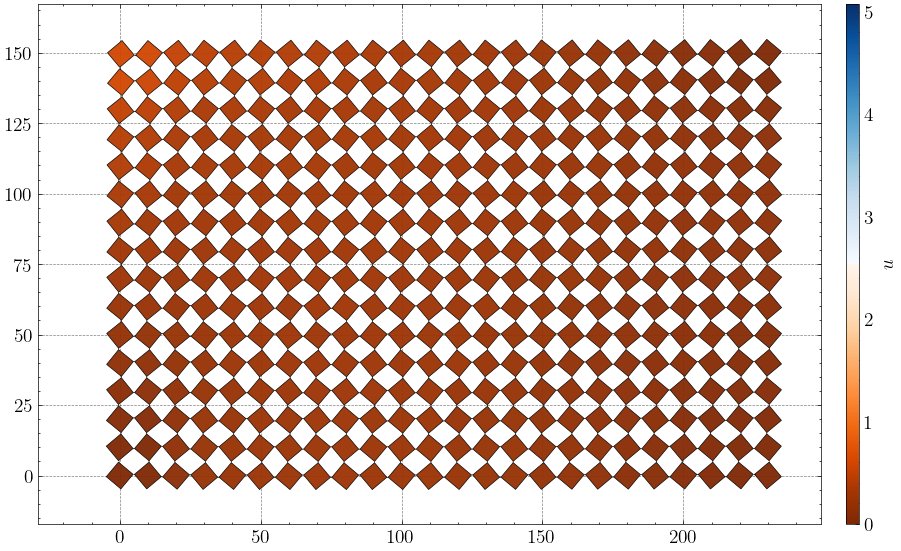

In [ ]:
xlim, ylim = problem.geometry.get_xy_limits(problem.initial_angle) + 1.*problem.geometry.spacing*jnp.array([-1, 1])

generate_animation(
    data=problem.solution_data,
    field="u",
    deformed=True,
    out_filename='test',#f"../../out/{problem.name}/{problem_filename}/animation",
    figsize=(9, 5.5),
    dpi=300,
    frame_range=jnp.arange(0, problem.solution_data.timepoints.shape[0]//2, 5),
    xlim=[-50, 270],
    ylim=[-20, 170],
    fps = 30,
)


### Calculate dilation and shear values with raw experimental data

In [ ]:
if run_and_save_data:
    for excitation_freq in jnp.arange(2, 36):
        print('excitation frequency = ', excitation_freq)

        video_num_5deg = get_video_num(excitation_freq, sample_initial_angle=5)
        video_num_30deg = get_video_num(excitation_freq, sample_initial_angle=30)
        video_path_5_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_5.0_degrees/F{str(video_num_5deg)}/F{str(video_num_5deg)}.mp4'
        video_path_30_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_30.0_degrees/F{str(video_num_30deg)}/F{str(video_num_30deg)}.mp4'
        data_info_30 = load_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth.pkl')
        data_info_5 = load_data(f'{video_path_5_degrees[:-7]}/solution_data_smooth.pkl')

        if excitation_freq == 23:
            data_info_30 = load_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth_ordered.pkl')

        n_cycles = 10
        end_frame = int((2*n_cycles/excitation_freq)*1000)
        if end_frame > data_info_30.fields.shape[0]:
            end_frame = data_info_30.fields.shape[0]

        data_info_30_fields = data_info_30.fields
        data_info_5_fields = data_info_5.fields

        time_steps = jnp.arange(end_frame)
        dilation_shear_dict5 = generate_SS_image_info_nonlinear_symmetric_UC_blocks(data_info_5_fields[:end_frame, 0, :, :], data_info_5.block_centroids, time_steps, geometry=problem.geometry)
        dilation_shear_dict30 = generate_SS_image_info_nonlinear_symmetric_UC_blocks(data_info_30_fields[:end_frame, 0, :, :], data_info_30.block_centroids, time_steps, geometry=problem.geometry)
        
        save_data(f'../../data/nonlinear_data/exp/{excitation_freq}Hz/one_block_UC/dilation_shear_data_5deg.pkl', dilation_shear_dict5)
        save_data(f'../../data/nonlinear_data/exp/{excitation_freq}Hz/one_block_UC/dilation_shear_data_30deg.pkl', dilation_shear_dict30)


In [ ]:
# fix up 23 Hz 30 degree sample data due to tracking being unordered
if run_and_save_data:
    fix_up_23_hz_data = False
    if fix_up_23_hz_data:
        excitation_freq = 23
        video_num_30deg = get_video_num(excitation_freq, sample_initial_angle=30)
        video_path_30_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_30.0_degrees/F{str(video_num_30deg)}/F{str(video_num_30deg)}.mp4'
        data_info_30 = load_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth.pkl')

        un_ordered_indexes = jnp.concatenate([jnp.array([19, 1, 2, 0]), jnp.arange(3, 17), jnp.array([20, 17, 21, 22, 18, 23, 33, 25, 26, 24, 27, 28, 34, 35, 29, 36, 37, 38, 30, 31, 39,
                                                                            32, 40, 41, 42, 43, 44, 45, 46, 47, 63, 50, 51, 48, 64, 52, 53, 54, 55, 56, 65, 57, 66, 58, 67, 59, 68, 60, 69, 61, 70, 62, 71, 49,
                                                                            72, 73, 74, 75, 76, 77, 78, 79, 81, 80, 82, 83, 84, 85, 86, 87, 88, 89, 95, 90, 91, 92, 93, 94, 105, 97, 98, 96, 99, 100, 101, 102, 106, 103, 107, 
                                                                            108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 104, 120]), jnp.arange(121, 146), jnp.array([148, 146, 149, 147, 150, 151, 152, 153, 157, 154, 158, 155, 159, 156, 160]), jnp.arange(161, 170),
                                                                            jnp.array([172, 170, 171, 173, 174, 175, 177, 176, 178, 179, 180, 181, 182, 183, 184, 185, 187, 186, 188, 189, 190, 191, 192, 193, 196, 194, 197, 195, 198, 199, 201, 200, 202, 203, 204, 205, 
                                                                                        209, 206, 207, 208, 210, 211, 212, 213, 214, 215, 216, 217, 219, 218, 220, 221]), jnp.arange(222, 240), jnp.array([243, 240, 241, 242, 244, 245, 246, 247, 249, 248, 250, 251, 253, 252, 254, 257, 255, 256, 258, 259, 260, 261, 262, 263, 264, 265, 268, 
                                                                                                                                                                                                            266, 267, 269, 271, 270, 272, 273, 274, 275, 276, 277, 278, 279, 281, 280, 282, 283, 284, 285, 286, 287, 291, 288, 289, 290, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305,
                                                                                                                                                                                                            308, 309, 306, 307, 310, 311, 312]), jnp.arange(313, 354), jnp.array([359, 354, 355, 356, 357, 358, 362, 363, 360, 361, 364, 365, 366, 367, 368, 369, 371, 370, 372, 373, 375, 376, 380, 377, 381, 378, 379, 374, 383, 382])])
        mod_block_centroids_ = jnp.zeros_like(data_info_30.block_centroids)
        mod_fields_ = jnp.zeros_like(data_info_30.fields)
        mod_CNV_ = jnp.zeros_like(data_info_30.centroid_node_vectors)
        mod_block_centroids = jnp.zeros_like(data_info_30.block_centroids)
        mod_fields = jnp.zeros_like(data_info_30.fields)
        mod_CNV = jnp.zeros_like(data_info_30.centroid_node_vectors)

        for i, idx in enumerate(un_ordered_indexes):
            mod_block_centroids = mod_block_centroids.at[i].set(data_info_30.block_centroids[idx])
            mod_fields_ = mod_fields_.at[:, :, i, :].set(data_info_30.fields[:, :, idx, :])
            mod_CNV = mod_CNV.at[i].set(data_info_30.centroid_node_vectors[idx])
        mod_block_centroids = mod_block_centroids - mod_block_centroids[0]
        mod_block_centroids = jnp.matmul(mod_block_centroids, rotation_matrix(jnp.pi))

        new_disps = jnp.matmul(mod_fields_[:, 0, :, :2], rotation_matrix(jnp.pi))
        new_vels = jnp.matmul(mod_fields_[:, 1, :, :2], rotation_matrix(jnp.pi))
        mod_fields = mod_fields.at[:, 0, :, :2].set(new_disps)
        mod_fields = mod_fields.at[:, 1, :, :2].set(new_vels)
        mod_fields = mod_fields.at[:, :, :, 2].set(mod_fields_[:, :, :, 2])

        data_info_30 = data_info_30._replace(block_centroids = mod_block_centroids)
        data_info_30 = data_info_30._replace(centroid_node_vectors = mod_CNV)
        data_info_30 = data_info_30._replace(fields = mod_fields)

        save_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth_ordered.pkl', data_info_30)
            

In [9]:
if run_and_save_data:
    dds_ratio_freqs5_exp, dds_ratio_freqs30_exp, ds_ratio_freqs5_exp, ds_ratio_freqs30_exp = [], [], [], []
    dds_avg_ratio_freqs5_exp, dds_avg_ratio_freqs30_exp, ds_avg_ratio_freqs5_exp, ds_avg_ratio_freqs30_exp = [], [], [], []

    temporal_signals5_exp, temporal_signals30_exp = [], []

    for excitation_freq in jnp.arange(2, 36):
        print('excitation frequency = ', excitation_freq)

        video_num_5deg = get_video_num(excitation_freq, sample_initial_angle=5)
        video_num_30deg = get_video_num(excitation_freq, sample_initial_angle=30)
        video_path_5_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_5.0_degrees/F{str(video_num_5deg)}/F{str(video_num_5deg)}.mp4'
        video_path_30_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_30.0_degrees/F{str(video_num_30deg)}/F{str(video_num_30deg)}.mp4'
        data_info_30 = load_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth.pkl')
        data_info_5 = load_data(f'{video_path_5_degrees[:-7]}/solution_data_smooth.pkl')

        if excitation_freq == 23:
            data_info_30 = load_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth_ordered.pkl')

        ds_dict5 = np.load(f'../../data/nonlinear_data/exp/{excitation_freq}Hz/one_block_UC/dilation_shear_data_5deg.pkl', allow_pickle=True)
        ds_dict30 = np.load(f'../../data/nonlinear_data/exp/{excitation_freq}Hz/one_block_UC/dilation_shear_data_30deg.pkl', allow_pickle=True)

        # Get quantities out from dictionaries
        d5 = jnp.sqrt(ds_dict5['d']**2)
        s_sq5 = ds_dict5['s_sq']

        d30 = jnp.sqrt(ds_dict30['d']**2)
        s_sq30 = ds_dict30['s_sq']

        n_cycles = 10
        end_frame = int((n_cycles/excitation_freq)*1000)
        frames_to_analyze = jnp.array([65, end_frame+64])
        last_ten_cycles_frames = jnp.array([frames_to_analyze[0], end_frame+64])

        ##### average the dilation and shear values #####
        d5_sq_avg = jnp.mean(d5**2, axis=1) # (n_timepoints,)
        d30_sq_avg = jnp.mean(d30**2, axis=1) # (n_timepoints,)

        s_sq5_avg = jnp.mean(s_sq5, axis=1) # (n_timepoints,)
        s_sq30_avg = jnp.mean(s_sq30, axis=1) # (n_timepoints,)

        
        ##### d^2 / (d^2 + s^2) #####
        dds_ratio_temp5 = jnp.sqrt(s_sq5_avg / (d5_sq_avg + s_sq5_avg)) # (n_timepoints,)
        dds_ratio_freq5 = jnp.mean(dds_ratio_temp5[last_ten_cycles_frames[0]:last_ten_cycles_frames[1]]) # (1,)
        dds_ratio_freqs5_exp.append(dds_ratio_freq5)

        dds_ratio_temp30 = jnp.sqrt(s_sq30_avg / (d30_sq_avg + s_sq30_avg)) # (n_timepoints,)
        dds_ratio_freq30 = jnp.mean(dds_ratio_temp30[last_ten_cycles_frames[0]:last_ten_cycles_frames[1]]) # (1,)
        dds_ratio_freqs30_exp.append(dds_ratio_freq30)

        end_time = (1.5*n_cycles/excitation_freq)+0.064
        if end_time > data_info_30.timepoints[-1]:
            end_time = data_info_30.timepoints[-1]

        temporal_signals5_exp.append(dds_ratio_temp5[:int(end_time*1000)])
        temporal_signals30_exp.append(dds_ratio_temp30[:int(end_time*1000)])

        
    save_data(f'../../data/nonlinear_data/exp/dilation_shear_across_frequencies_5deg.pkl', dds_ratio_freqs5_exp)
    save_data(f'../../data/nonlinear_data/exp/dilation_shear_across_frequencies_30deg.pkl', dds_ratio_freqs30_exp)

excitation frequency =  2
excitation frequency =  3
excitation frequency =  4
excitation frequency =  5
excitation frequency =  6
excitation frequency =  7
excitation frequency =  8
excitation frequency =  9
excitation frequency =  10
excitation frequency =  11
excitation frequency =  12
excitation frequency =  13
excitation frequency =  14
excitation frequency =  15
excitation frequency =  16
excitation frequency =  17
excitation frequency =  18
excitation frequency =  19
excitation frequency =  20
excitation frequency =  21
excitation frequency =  22
excitation frequency =  23
excitation frequency =  24
excitation frequency =  25
excitation frequency =  26
excitation frequency =  27
excitation frequency =  28
excitation frequency =  29
excitation frequency =  30
excitation frequency =  31
excitation frequency =  32
excitation frequency =  33
excitation frequency =  34
excitation frequency =  35
Data saved at ../../data/nonlinear_data/exp/dilation_shear_across_frequencies_5deg.pkl
Dat

(0.0, 1.0)

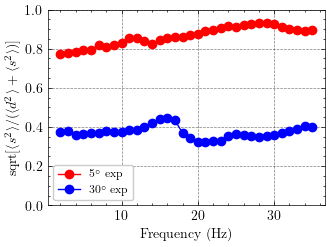

In [11]:
dds_ratio_freqs5_exp_loaded = np.load(f'../../data/nonlinear_data/exp/dilation_shear_across_frequencies_5deg.pkl', allow_pickle=True)
dds_ratio_freqs30_exp_loaded = np.load(f'../../data/nonlinear_data/exp/dilation_shear_across_frequencies_30deg.pkl', allow_pickle=True)

frequencies = jnp.arange(2, 36)
plt.figure()
plt.plot(frequencies, dds_ratio_freqs5_exp_loaded, color='r', marker='o', label='$5^{\circ}$ exp')
plt.plot(frequencies, dds_ratio_freqs30_exp_loaded, color='b', marker='o', label='$30^{\circ}$ exp')
plt.ylabel('sqrt[$ \langle s^2 \\rangle / (\langle d^2 \\rangle + \langle s^2 \\rangle)$]')
plt.xlabel('Frequency (Hz)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.ylim(0,1)

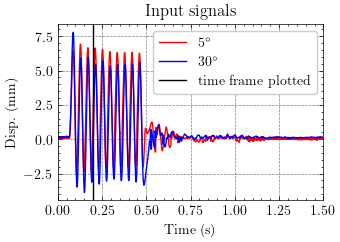

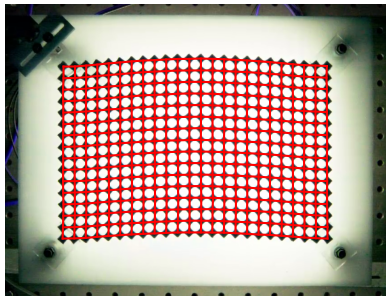

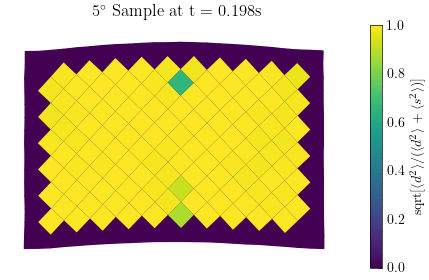

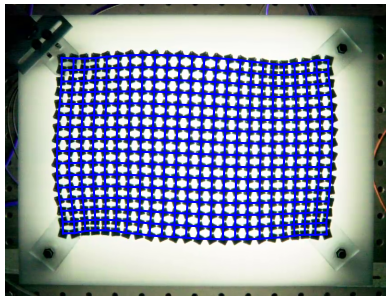

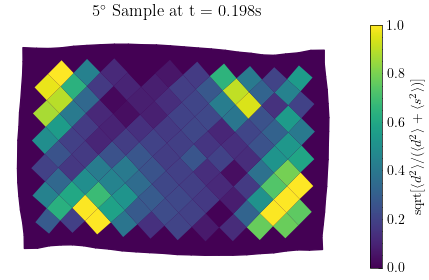

In [12]:
# Spatial plots
excitation_freq = 24
time_frame = 198

video_num_5deg = get_video_num(excitation_freq, sample_initial_angle=5)
video_num_30deg = get_video_num(excitation_freq, sample_initial_angle=30)
video_path_5_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_5.0_degrees/F{str(video_num_5deg)}/F{str(video_num_5deg)}.mp4'
video_path_30_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_30.0_degrees/F{str(video_num_30deg)}/F{str(video_num_30deg)}.mp4'
data_info_30 = load_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth.pkl')
data_info_5 = load_data(f'{video_path_5_degrees[:-7]}/solution_data_smooth.pkl')

ds_dict5 = np.load(f'../../data/nonlinear_data/exp/{excitation_freq}Hz/one_block_UC/dilation_shear_data_5deg.pkl', allow_pickle=True)
ds_dict30 = np.load(f'../../data/nonlinear_data/exp/{excitation_freq}Hz/one_block_UC/dilation_shear_data_30deg.pkl', allow_pickle=True)

# Get quantities out from dictionaries
d5 = jnp.sqrt(ds_dict5['d']**2)
s_sq5 = ds_dict5['s_sq']

d30 = jnp.sqrt(ds_dict30['d']**2)
s_sq30 = ds_dict30['s_sq']

n_cycles = 10
end_frame = int((n_cycles/excitation_freq)*1000)
frames_to_analyze = jnp.array([65, end_frame+64])
last_ten_cycles_frames = jnp.array([frames_to_analyze[0], end_frame+64])

##### d^2 / (d^2 + s^2) #####
dds_ratio5 = jnp.sqrt(s_sq5[time_frame] / (d5[time_frame]**2 + s_sq5[time_frame])) # (n_unit_cells,)
dds_ratio30 = jnp.sqrt(s_sq30[time_frame] / (d30[time_frame]**2 + s_sq30[time_frame])) # (n_unit_cells,)

plt.figure()
plt.plot(data_info_5.timepoints, jnp.sqrt(data_info_5.fields[:, 0, 360, 0]**2 + data_info_5.fields[:, 0, 360, 1]**2)*jnp.sign(data_info_5.fields[:, 0, 360, 0]), 'r', label='$5^\circ$')
plt.plot(data_info_30.timepoints, jnp.sqrt(data_info_30.fields[:, 0, 360, 0]**2 + data_info_30.fields[:, 0, 360, 1]**2)*jnp.sign(data_info_30.fields[:, 0, 360, 0]), 'b', label='$30^\circ$')
plt.axvline(time_frame*10**(-3), color='k', label='time frame plotted')
plt.legend()
plt.xlim([0, 1.5])
plt.title('Input signals')
plt.ylabel('Disp. (mm)')
plt.xlabel('Time (s)')
plt.tight_layout()

show_current_frame(
        video_path_5_degrees, 
        time_frame, 
        geometry_figure, 
        data_info_5, 
        line_color='r', 
        lw=1.5, 
        xlim=(182, 1030), 
        ylim=(40, 690), 
        mesh=True, 
        figsize=(4.6,3),
        calib_xy=[0.3915, 0.3915], 
        zero_idx_block_loc=[310.54, 169.18], 
        out_dir='out',
        figure_extension='svg', 
        save=False)

generate_dilation_shear_ratio_heatmap_blocks(    
    data_info=data_info_5, 
    problem=problem,
    ds_dict=ds_dict5,
    dds_ratio=dds_ratio5,
    time_frame=time_frame, 
    cmap='viridis', 
    figsize=(4.6, 3), 
    xlim=[-15, 250], 
    ylim=[-15, 170], 
    title=f'$5^\circ$ Sample at t = {time_frame*10**(-3)}s')

show_current_frame(
        video_path_30_degrees, 
        time_frame, 
        geometry_figure, 
        data_info_30, 
        line_color='b', 
        lw=1.5, 
        xlim=(182, 1030), 
        ylim=(40, 690), 
        figsize=(4.6,3),
        mesh=True, 
        calib_xy=[0.3915, 0.3915], 
        zero_idx_block_loc=[311.3, 180.78], 
        out_dir='out',
        figure_extension='svg', 
        save=False)

generate_dilation_shear_ratio_heatmap_blocks(    
    data_info=data_info_30, 
    problem=problem,
    ds_dict=ds_dict30,
    dds_ratio=dds_ratio30,
    time_frame=time_frame, 
    cmap='viridis', 
    figsize=(4.6, 3), 
    xlim=[-15, 250], 
    ylim=[-15, 170], 
    title=f'$5^\circ$ Sample at t = {time_frame*10**(-3)}s')

### Run forward simulations with experimental input, save the data, and calculate dilation and shear values

In [ ]:
# Run the simulations with the experimental driving signal and save the solution data
run_and_save_data  = False
if run_and_save_data:
    for excitation_freq in jnp.arange(2, 36):
        print('excitation_freq = ', excitation_freq)

        video_num_5deg = get_video_num(excitation_freq, sample_initial_angle=5)
        video_num_30deg = get_video_num(excitation_freq, sample_initial_angle=30)

        video_path_input5 = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_5.0_degrees/F{str(video_num_5deg)}/F{str(video_num_5deg)}.mp4'
        video_path_input30 = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_30.0_degrees/F{str(video_num_30deg)}/F{str(video_num_30deg)}.mp4'

        video_input_folder_path5 = video_path_input5[:-len(video_path_input5.split('/')[-1])]
        exp_input_solution_data5 = load_data(f"{video_input_folder_path5}/solution_data_smooth.pkl")
        exp_input_solution5 = exp_input_solution_data5.fields
        ref_block5 = exp_input_solution5[:, 0, 0, :] # correct for some camera shakiness
        loaded_exp_input_driving_signal5 = jnp.sqrt((exp_input_solution5[:, 0, 360, 0] - ref_block5[:, 0])**2 + (exp_input_solution5[:, 0, 360, 1]-ref_block5[:, 1])**2)*jnp.sign((exp_input_solution5[:, 0, 360, 0]-ref_block5[:, 0]))

        video_input_folder_path30 = video_path_input30[:-len(video_path_input30.split('/')[-1])]
        exp_input_solution_data30 = load_data(f"{video_input_folder_path30}/solution_data_smooth.pkl")
        if excitation_freq == 23:
            exp_input_solution_data30 = load_data(f"{video_input_folder_path30}/solution_data_smooth_ordered.pkl")
        exp_input_solution30 = exp_input_solution_data30.fields
        ref_block30 = exp_input_solution30[:, 0, 0, :] # correct for some camera shakiness
        loaded_exp_input_driving_signal30 = jnp.sqrt((exp_input_solution30[:, 0, 360, 0]-ref_block30[:, 0])**2 + (exp_input_solution30[:, 0, 360, 1]-ref_block30[:, 1])**2)*jnp.sign((exp_input_solution30[:, 0, 360, 0]-ref_block30[:, 0]))
        
        fps = 1000
        simulation_time = len(loaded_exp_input_driving_signal30)/fps
        timepoints = jnp.linspace(0, simulation_time, len(loaded_exp_input_driving_signal30))
        use_contact = True
        clamped_corners = True
        atol = 1e-4

        problem_validate5 = ForwardProblem(
            n1_blocks=n1_blocks,
            n2_blocks=n2_blocks,
            spacing=spacing,
            bond_length=hinge_length,
            initial_angle=5*jnp.pi/180,
            k_stretch=k_stretch,
            k_shear=k_shear,
            k_rot=k_rot,
            density=density,
            damping=damping,
            internal_damping=internal_damping,
            damped_bonds_active=True,
            simulation_time=simulation_time,
            loaded_side=loaded_side,
            n_excited_blocks=n_excited_blocks,
            exp_driving_signal=True,
            exp_driving_signal_data=loaded_exp_input_driving_signal5,
            driving_angle=driving_angle,
            use_contact=use_contact,
            clamped_corners=clamped_corners,
            atol=atol,
        )
        problem_validate5.setup()
        problem_validate5.solution_data = problem_validate5.solve()

        problem_validate30 = ForwardProblem(
            n1_blocks=n1_blocks,
            n2_blocks=n2_blocks,
            spacing=spacing,
            bond_length=hinge_length,
            initial_angle=30*jnp.pi/180,
            k_stretch=k_stretch,
            k_shear=k_shear,
            k_rot=k_rot,
            density=density,
            damping=damping,
            internal_damping=internal_damping,
            damped_bonds_active=True,
            simulation_time=simulation_time,
            loaded_side=loaded_side,
            n_excited_blocks=n_excited_blocks,
            exp_driving_signal=True,
            exp_driving_signal_data=loaded_exp_input_driving_signal30,
            driving_angle=driving_angle,
            use_contact=use_contact,
            clamped_corners=clamped_corners,
            atol=atol,
        )
        problem_validate30.setup()
        problem_validate30.solution_data = problem_validate30.solve()

        save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_validate30.k_stretch:.2f}_k_shear_{problem_validate30.k_shear:.2f}_k_rot_{problem_validate30.k_rot:.2f}/exp_harmonic_input/{excitation_freq:.0f}Hz/solution_data_initial_angle_30_remove_shakiness.pkl', problem_validate30.solution_data)
        save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_validate30.k_stretch:.2f}_k_shear_{problem_validate30.k_shear:.2f}_k_rot_{problem_validate30.k_rot:.2f}/exp_harmonic_input/{excitation_freq:.0f}Hz/solution_data_initial_angle_5_remove_shakiness.pkl', problem_validate5.solution_data)


In [ ]:
# calculate the dilation and shear values
run_and_save_data  = False
if run_and_save_data:
    for excitation_freq in jnp.arange(2, 36):
        print('excitation frequency = ', excitation_freq)

        data_info_5 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/solution_data_initial_angle_5_remove_shakiness.pkl')
        data_info_30 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/solution_data_initial_angle_30_remove_shakiness.pkl')
        
        data_info_30_fields = data_info_30.fields
        # data_info_30_fields = data_info_30_fields.at[:64, 0, :, :].set(0.)

        data_info_5_fields = data_info_5.fields
        # data_info_5_fields = data_info_5_fields.at[:64, 0, :, :].set(0.)

        n_cycles = 10
        end_frame = int((2*n_cycles/excitation_freq)*1000)
        if end_frame > data_info_30.fields.shape[0]:
            end_frame = data_info_30.fields.shape[0]

        time_steps = jnp.arange(end_frame)
        dilation_shear_dict5 = generate_SS_image_info_nonlinear_symmetric_UC_blocks(data_info_5_fields[:end_frame, 0, :, :], data_info_5.block_centroids, time_steps, geometry=problem.geometry)
        dilation_shear_dict30 = generate_SS_image_info_nonlinear_symmetric_UC_blocks(data_info_30_fields[:end_frame, 0, :, :], data_info_30.block_centroids, time_steps, geometry=problem.geometry)

        save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/dilation_shear_data_5deg.pkl', dilation_shear_dict5)
        save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/dilation_shear_data_30deg.pkl', dilation_shear_dict30)

        

In [47]:
run_and_save_data = False
if run_and_save_data:
    dds_ratio_freqs5, dds_ratio_freqs30, ds_ratio_freqs5, ds_ratio_freqs30 = [], [], [], []
    dds_avg_ratio_freqs5, dds_avg_ratio_freqs30, ds_avg_ratio_freqs5, ds_avg_ratio_freqs30 = [], [], [], []

    temporal_signals5_sim, temporal_signals30_sim = [], []
    plot_temporal_signals = False
    for excitation_freq in jnp.arange(2, 36):
        print('excitation frequency = ', excitation_freq)

        data_info_5 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/solution_data_initial_angle_5_remove_shakiness.pkl')
        data_info_30 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/solution_data_initial_angle_30_remove_shakiness.pkl')

        ds_dict5 = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/dilation_shear_data_5deg.pkl', allow_pickle=True)
        ds_dict30 = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/dilation_shear_data_30deg.pkl', allow_pickle=True)

        # Get quantities out from dictionaries
        d5 = jnp.sqrt(ds_dict5['d']**2)
        s_sq5 = ds_dict5['s_sq']

        d30 = jnp.sqrt(ds_dict30['d']**2)
        s_sq30 = ds_dict30['s_sq']

        n_cycles = 10
        end_frame = int((n_cycles/excitation_freq)*1000)
        frames_to_analyze = jnp.array([65, end_frame+64])
        last_ten_cycles_frames = jnp.array([frames_to_analyze[0], end_frame+64])

        ##### average the dilation and shear values #####
        d5_sq_avg = jnp.mean(d5**2, axis=1) # (n_timepoints,)
        d30_sq_avg = jnp.mean(d30**2, axis=1) # (n_timepoints,)

        s_sq5_avg = jnp.mean(s_sq5, axis=1) # (n_timepoints,)
        s_sq30_avg = jnp.mean(s_sq30, axis=1) # (n_timepoints,)
        

        ##### d^2 / (d^2 + s^2) #####
        dds_ratio_temp5 = jnp.sqrt(s_sq5_avg / (d5_sq_avg + s_sq5_avg)) # (n_timepoints,)
        dds_ratio_freq5 = jnp.mean(dds_ratio_temp5[last_ten_cycles_frames[0]:last_ten_cycles_frames[1]]) # (1,)
        dds_ratio_freqs5.append(dds_ratio_freq5)

        dds_ratio_temp30 = jnp.sqrt(s_sq30_avg / (d30_sq_avg + s_sq30_avg)) # (n_timepoints,)
        dds_ratio_freq30 = jnp.mean(dds_ratio_temp30[last_ten_cycles_frames[0]:last_ten_cycles_frames[1]]) # (1,)
        dds_ratio_freqs30.append(dds_ratio_freq30)

        
        end_time = (1.5*n_cycles/excitation_freq)
        if end_time > data_info_30.timepoints[-1]:
            end_time = data_info_30.timepoints[-1]

        if plot_temporal_signals:
            plt.figure(figsize=(2,3.5))#figsize=[3,4])
            plt.plot(data_info_5.timepoints[:int(end_time*1000)], dds_ratio_temp5[:int(end_time*1000)], color='r', label='$5^{\circ}$')
            plt.plot(data_info_30.timepoints[:int(end_time*1000)], dds_ratio_temp30[:int(end_time*1000)], color='b', label='$30^{\circ}$')
            plt.xlim([0, end_time])
            plt.ylim([0, 1.4])
            plt.xlabel('Time (s)')
            plt.ylabel('sqrt[$ \langle s^2 \\rangle / (\langle d^2 \\rangle + \langle s^2 \\rangle)$]')
            plt.title(f'{excitation_freq} Hz')
            plt.legend()
            plt.grid(False)
            plt.tight_layout()


        temporal_signals5_sim.append(dds_ratio_temp5[:int(end_time*1000)])
        temporal_signals30_sim.append(dds_ratio_temp30[:int(end_time*1000)])

    save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/dilation_shear_across_frequencies_5deg.pkl', dds_ratio_freqs5)
    save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/dilation_shear_across_frequencies_30deg.pkl', dds_ratio_freqs30)

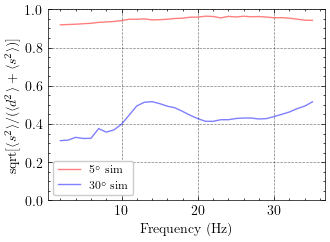

In [48]:
dds_ratio_freqs5_loaded = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/dilation_shear_across_frequencies_5deg.pkl', allow_pickle=True)
dds_ratio_freqs30_loaded = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/dilation_shear_across_frequencies_30deg.pkl', allow_pickle=True)

frequencies = jnp.arange(2, 36)
plt.figure()
plt.plot(frequencies, dds_ratio_freqs5_loaded, color='r', alpha=0.5, label='$5^{\circ}$ sim')
plt.plot(frequencies, dds_ratio_freqs30_loaded, color='b', alpha=0.5, label='$30^{\circ}$ sim')
plt.ylabel('sqrt[$ \langle s^2 \\rangle / (\langle d^2 \\rangle + \langle s^2 \\rangle)$]')
plt.xlabel('Frequency (Hz)')
plt.legend(fontsize=8)
plt.ylim([0, 1])
plt.tight_layout()

### Look at snapshots of experiment and simulation with experimental input for model validation

In [16]:
def compute_field_values(data: SolutionData, field):
    if field == "ux":
        field_values = data.fields[:, 0, :, 0]
    elif field == "uy":
        field_values = data.fields[:, 0, :, 1]
    elif field == "theta":
        field_values = data.fields[:, 0, :, 2]
    elif field == "vx":
        field_values = data.fields[:, 1, :, 0]
    elif field == "vy":
        field_values = data.fields[:, 1, :, 1]
    elif field == "omega":
        field_values = data.fields[:, 1, :, 2]
    elif field == "u":
        field_values = (data.fields[:, 0, :, 0] **
                        2 + data.fields[:, 0, :, 1]**2)**0.5
    elif field == "v":
        field_values = (data.fields[:, 1, :, 0] **
                        2 + data.fields[:, 1, :, 1]**2)**0.5
    elif field == "theta_abs":
        field_values = np.abs(data.fields[:, 0, :, 2])
    else:
        raise ValueError

    return field_values

def plot_video_frame_field_overlaid(
        video_filename: Union[str, Path],
        solution_data: SolutionData,
        frame_number: int,
        timepoint: int,
        field: str,
        calib_xy: Tuple[float, float],
        ROI_X: Tuple[float, float] = (0, -1),
        ROI_Y: Tuple[float, float] = (0, -1),
        field_values: Optional[np.ndarray] = None,
        vmin: Optional[float] = None,
        vmax: Optional[float] = None,
        alpha_overlay=0.8,
        shift_px=(0, 0),
        cmap="inferno",
        figsize=(8, 5),
        ax=None,):
    """Plot a frame of the video overlaid with the field values of the blocks.

    Args:
        video_filename (Union[str, Path]): Path to the video file.
        solution_data (SolutionData): Solution data.
        frame_number (int): Frame number to plot.
        timepoint (int): Timepoint of the solution data.
        field (str): Field to plot.
        calib_xy (Tuple[float, float]): Calibration factors for x and y.
        ROI_X (tuple[int, int], optional): ROI in the x-direction. If -1 is provided, the whole frame will be used. Defaults to (0, -1).
        ROI_Y (tuple[int, int], optional): ROI in the y-direction. If -1 is provided, the whole frame will be used. Defaults to (0, -1).
        field_values (Optional[np.ndarray], optional): Field values. Defaults to None.
        vmin (Optional[float], optional): Minimum value of the field. Defaults to None.
        vmax (Optional[float], optional): Maximum value of the field. Defaults to None.
        alpha_overlay (float, optional): Alpha of the overlay. Defaults to 0.8.
        shift_px (Tuple[int, int], optional): Shift in pixels for alignment. Defaults to (0, 0).
        cmap (str, optional): Colormap. Defaults to "inferno".
        figsize (Tuple[int, int], optional): Figure size. Defaults to (8, 5).
        ax ([type], optional): Axes. Defaults to None.

    Returns:
        Tuple[plt.Figure, plt.Axes]: Figure and axes.
    """

    # Load the video using opencv
    video = cv2.VideoCapture(f"{video_filename}")
    # Get frame number
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    # Read the frame
    _, frame = video.read()
    # Add alpha channel
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2RGBA)
    # Restrict the frame to the ROI
    frame = cv2.flip(frame, 0)
    ROI_X = (ROI_X[0], ROI_X[1] if ROI_X[1] > 0 else frame.shape[1])
    ROI_Y = (ROI_Y[0], ROI_Y[1] if ROI_Y[1] > 0 else frame.shape[0])
    flipped_ROI_Y = (frame.shape[0] - ROI_Y[1], frame.shape[0] - ROI_Y[0])
    ROI_XY = (ROI_X, flipped_ROI_Y)
    frame = frame[ROI_XY[1][0]: ROI_XY[1][1], ROI_XY[0][0]: ROI_XY[0][1]]
    shift_px = np.array(shift_px)

    # Compute current configuration of the blocks
    block_coordinates = current_coordinates(
        vertices=solution_data.centroid_node_vectors,
        centroids=solution_data.block_centroids,
        angles=solution_data.fields[timepoint, 0, :, 2],
        displacements=solution_data.fields[timepoint, 0, :, :2],
    )
    # Compute the field values
    field_values_all_times = compute_field_values(
        solution_data, field) if field_values is None else field_values
    field_values_min = field_values_all_times.min() if vmin is None else vmin
    field_values_max = field_values_all_times.max() if vmax is None else vmax
    _field_values = field_values_all_times[timepoint]
    # Make a colormap
    cmap = plt.get_cmap(cmap)
    # Normalize the field values
    norm = plt.Normalize(vmin=field_values_min, vmax=field_values_max)
    # Map the normalized values to colors
    field_colors = cmap(norm(_field_values))
    # Draw the blocks
    overlay = frame.copy()
    for block, color in zip(block_coordinates, field_colors):
        # Convert the block coordinates to pixels
        block_px = (np.array(block) / calib_xy[0]).astype(int) + shift_px
        # Draw the shape with the color and opacity 0.5
        cv2.fillPoly(
            overlay,
            pts=[block_px],
            # Color the block according to the field value
            color=(color[0]*255, color[1]*255, color[2]*255, 255),
        )
    # Add the overlay to the frame
    frame = cv2.addWeighted(overlay, alpha_overlay, frame, 1-alpha_overlay, 0)

    # Show the frame
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(frame, origin="lower")
    ax.axis("off")
    # TODO:
    # Add colorbar option
    # Add timestamp label option
    fig = ax.get_figure()

    return fig, ax

def get_video_num(excitation_freq, sample_initial_angle):
        if sample_initial_angle == 5:
            exp_video_nums = np.arange(34, 0, -1)
            exp_excitation_freqs = np.arange(2, 36)

            idx = np.where(exp_excitation_freqs == excitation_freq)[0][0]
            video_num = exp_video_nums[idx]
        elif sample_initial_angle == 30:
            exp_video_nums = np.arange(44, 10, -1)
            exp_excitation_freqs = np.arange(2, 36)

            idx = np.where(exp_excitation_freqs == excitation_freq)[0][0]
            video_num = exp_video_nums[idx]
        
        return video_num

def generate_animation_overlaid_frames(data: SolutionData, field, experimental_video_path, frame_range, calib_xy, shift_px, out_path, fps=20, figsize=[10,8], dpi=500):
    
    temporary_folder_name = 'images_temporary'
    for i in frame_range:
        plot_video_frame_field_overlaid(
            video_filename=experimental_video_path,
            solution_data=data,
            frame_number=int(i),
            timepoint=int(i),
            field=field,
            calib_xy=calib_xy,
            shift_px=shift_px)
        save_figure(temporary_folder_name, f'frame_{i}', 'png', dpi=500, close_fig=True)

    images = []
    for i in frame_range:
        images.append(Image.open(f'{temporary_folder_name}/frame_{i}.png'))

    frames = [] # for storing the generated images
    fig = plt.figure(figsize=figsize)
    for i in jnp.arange(len(images)):
        frames.append([plt.imshow(images[i],animated=True)])

    print('generating_animation')
    ani = animation.ArtistAnimation(fig, frames, interval=1, blit=True,
                                    repeat_delay=100)
    print('setting axis off')
    plt.gca().set_axis_off()
    print('saving')
    ani.save(out_path, dpi=dpi, fps=fps)

    # remove temporary folder
    shutil.rmtree(temporary_folder_name)

KeyboardInterrupt: 

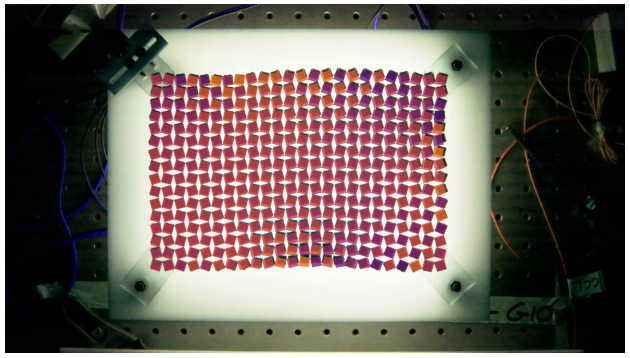

In [17]:
excitation_freq = 24

video_num_5deg = get_video_num(excitation_freq, sample_initial_angle=5)
video_num_30deg = get_video_num(excitation_freq, sample_initial_angle=30)
video_path_5_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_5.0_degrees/F{str(video_num_5deg)}/F{str(video_num_5deg)}.mp4'
video_path_30_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_30.0_degrees/F{str(video_num_30deg)}/F{str(video_num_30deg)}.mp4'
exp_data_info_30 = load_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth.pkl')
exp_data_info_5 = load_data(f'{video_path_5_degrees[:-7]}/solution_data_smooth.pkl')

num_data_info_5 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/solution_data_initial_angle_5_remove_shakiness.pkl')
num_data_info_30 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/{excitation_freq:.0f}Hz/solution_data_initial_angle_30_remove_shakiness.pkl')
    
generate_animation_overlaid_frames(data=num_data_info_30, 
                                field='theta', 
                                experimental_video_path=video_path_30_degrees, 
                                frame_range=jnp.arange(60, 800, 5), 
                                calib_xy=[0.3915, 0.3915], 
                                shift_px=(312, 180),  
                                out_path='video30.mp4', 
                                figsize=[10,8], 
                                dpi=150)

generate_animation_overlaid_frames(data=num_data_info_5, 
                                field='theta', 
                                experimental_video_path=video_path_5_degrees, 
                                frame_range=jnp.arange(60, 800, 5), 
                                calib_xy=[0.3915, 0.3915], 
                                shift_px=(312, 170),  
                                out_path='video5.mp4', 
                                figsize=[10,8], 
                                dpi=150)

### Extract accelerations and reaction forces for experiments and simulations ran with raw experimental input

In [ ]:
k_contact = 1.
min_angle = 0.*jnp.pi/180.
cutoff_angle = 5.*jnp.pi/180.

problem5 = ForwardProblem(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=hinge_length,
    initial_angle=5.*jnp.pi/180.,
    k_stretch=k_stretch,
    k_shear=k_shear,
    k_rot=k_rot,
    density=density,
    damping=damping,
    internal_damping=internal_damping,
    damped_bonds_active=damped_bonds_active,
    simulation_time=simulation_time,
    loaded_side=loaded_side,
    n_excited_blocks=n_excited_blocks,
    exp_driving_signal=exp_driving_signal,
    exp_driving_signal_data=exp_driving_signal_data,
    driving_angle=driving_angle,
    use_contact=use_contact,
    clamped_corners=clamped_corners,
    atol=atol,
)
problem5.setup()

problem30 = ForwardProblem(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=hinge_length,
    initial_angle=30.*jnp.pi/180.,
    k_stretch=k_stretch,
    k_shear=k_shear,
    k_rot=k_rot,
    density=density,
    damping=damping,
    internal_damping=internal_damping,
    damped_bonds_active=damped_bonds_active,
    simulation_time=simulation_time,
    loaded_side=loaded_side,
    n_excited_blocks=n_excited_blocks,
    exp_driving_signal=exp_driving_signal,
    exp_driving_signal_data=exp_driving_signal_data,
    driving_angle=driving_angle,
    use_contact=use_contact,
    clamped_corners=clamped_corners,
    atol=atol,
)
problem30.setup()

control_params5 = ControlParams(
                    geometrical_params=GeometricalParams(
                        block_centroids=problem5.geometry.block_centroids(5*jnp.pi/180.),
                        centroid_node_vectors=problem5.geometry.centroid_node_vectors(5*jnp.pi/180.),
                    ),
                    mechanical_params=MechanicalParams(
                        bond_params=LigamentParams(
                            k_stretch=k_stretch,
                            k_shear=k_shear,
                            k_rot=k_rot,
                            reference_vector=problem5.geometry.reference_bond_vectors(),
                        ),
                        density=density,
                        damping=damping,
                        internal_damping=internal_damping,
                        contact_params=ContactParams(
                            k_contact=k_contact,
                            min_angle=min_angle,
                            cutoff_angle=cutoff_angle,
                        ),
                    ),
                    constraint_params=dict(
                        amplitude=1.,
                    ),
                )

control_params30 = ControlParams(
                    geometrical_params=GeometricalParams(
                        block_centroids=problem30.geometry.block_centroids(30*jnp.pi/180.),
                        centroid_node_vectors=problem30.geometry.centroid_node_vectors(30*jnp.pi/180.),
                    ),
                    mechanical_params=MechanicalParams(
                        bond_params=LigamentParams(
                            k_stretch=k_stretch,
                            k_shear=k_shear,
                            k_rot=k_rot,
                            reference_vector=problem30.geometry.reference_bond_vectors(),
                        ),
                        density=density,
                        damping=damping,
                        internal_damping=internal_damping,
                        contact_params=ContactParams(
                            k_contact=k_contact,
                            min_angle=min_angle,
                            cutoff_angle=cutoff_angle,
                        ),
                    ),
                    constraint_params=dict(
                        amplitude=1.,
                    ),
                )


In [ ]:
# Calculate the accelerations
if run_and_save_data:
    for excitation_freq in jnp.arange(2, 36):
        print('excitation frequency = ', excitation_freq)
        
        ####### EXPERIMENTS #######
        video_num_5deg = get_video_num(excitation_freq, sample_initial_angle=5)
        video_num_30deg = get_video_num(excitation_freq, sample_initial_angle=30)
        video_path_5_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_5.0_degrees/F{str(video_num_5deg)}/F{str(video_num_5deg)}.mp4'
        video_path_30_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_30.0_degrees/F{str(video_num_30deg)}/F{str(video_num_30deg)}.mp4'
        data_info_30 = load_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth.pkl')
        data_info_5 = load_data(f'{video_path_5_degrees[:-7]}/solution_data_smooth.pkl')

        smoothing_window_acc = 10
        raw_velocities5, smoothed_velocities5, raw_accelerations5, smoothed_accelerations5 = get_accelerations(data_info_5, problem5, smoothing_window=smoothing_window_acc)
        raw_velocities30, smoothed_velocities30, raw_accelerations30, smoothed_accelerations30 = get_accelerations(data_info_30, problem30, smoothing_window=smoothing_window_acc)

        save_data(f'../../data/nonlinear_data/reaction_forces/raw_exp_data/5_deg_sample/{excitation_freq}Hz/raw_interpolated_accelerations.npy', raw_accelerations5)
        save_data(f'../../data/nonlinear_data/reaction_forces/raw_exp_data/5_deg_sample/{excitation_freq}Hz/smoothed{smoothing_window_acc}_interp_accelerations.npy', smoothed_accelerations5)

        save_data(f'../../data/nonlinear_data/reaction_forces/raw_exp_data/30_deg_sample/{excitation_freq}Hz/raw_interpolated_accelerations.npy', raw_accelerations30)
        save_data(f'../../data/nonlinear_data/reaction_forces/raw_exp_data/30_deg_sample/{excitation_freq}Hz/smoothed{smoothing_window_acc}_interp_accelerations.npy', smoothed_accelerations30)


        ####### SIMULATIONS #######
        data_info_30 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem30.k_stretch:.2f}_k_shear_{problem30.k_shear:.2f}_k_rot_{problem30.k_rot:.2f}/exp_harmonic_input_constrained/{excitation_freq:.0f}Hz/solution_data_initial_angle_30_remove_shakiness.pkl')
        data_info_5 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem5.k_stretch:.2f}_k_shear_{problem5.k_shear:.2f}_k_rot_{problem5.k_rot:.2f}/exp_harmonic_input_constrained/{excitation_freq:.0f}Hz/solution_data_initial_angle_5_remove_shakiness.pkl')

        smoothing_window_acc = 10
        raw_velocities5, smoothed_velocities5, raw_accelerations5, smoothed_accelerations5 = get_accelerations(data_info_5, problem5, smoothing_window=smoothing_window_acc)
        raw_velocities30, smoothed_velocities30, raw_accelerations30, smoothed_accelerations30 = get_accelerations(data_info_30, problem30, smoothing_window=smoothing_window_acc)

        save_data(f'../../data/nonlinear_data/reaction_forces/exp_harmonic_input_constrained/5_deg_sample/{excitation_freq}Hz/raw_interpolated_accelerations.npy', raw_accelerations5)
        save_data(f'../../data/nonlinear_data/reaction_forces/exp_harmonic_input_constrained/5_deg_sample/{excitation_freq}Hz/smoothed{smoothing_window_acc}_interp_accelerations.npy', smoothed_accelerations5)

        save_data(f'../../data/nonlinear_data/reaction_forces/exp_harmonic_input_constrained/30_deg_sample/{excitation_freq}Hz/raw_interpolated_accelerations.npy', raw_accelerations30)
        save_data(f'../../data/nonlinear_data/reaction_forces/exp_harmonic_input_constrained/30_deg_sample/{excitation_freq}Hz/smoothed{smoothing_window_acc}_interp_accelerations.npy', smoothed_accelerations30)


In [ ]:
# Calculate the reaction forces
if run_and_save_data:
    for excitation_freq in jnp.arange(2, 36):
        print('excitation frequency = ', excitation_freq)

        ####### EXPERIMENTS #######
        video_num_5deg = get_video_num(excitation_freq, sample_initial_angle=5)
        video_num_30deg = get_video_num(excitation_freq, sample_initial_angle=30)
        video_path_5_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_5.0_degrees/F{str(video_num_5deg)}/F{str(video_num_5deg)}.mp4'
        video_path_30_degrees = f'../../data/dilational_metamaterials/harmonic_excitation/finer_sweep/initial_angle_30.0_degrees/F{str(video_num_30deg)}/F{str(video_num_30deg)}.mp4'
        data_info_30 = load_data(f'{video_path_30_degrees[:-8]}/solution_data_smooth.pkl')
        data_info_5 = load_data(f'{video_path_5_degrees[:-7]}/solution_data_smooth.pkl')

        interp_accelerations5 = np.load(f'../../data/nonlinear_data/reaction_forces/raw_exp_data/5_deg_sample/{excitation_freq}Hz/raw_interpolated_accelerations.npy', allow_pickle=True)
        interp_accelerations30 = np.load(f'../../data/nonlinear_data/reaction_forces/raw_exp_data/30_deg_sample/{excitation_freq}Hz/raw_interpolated_accelerations.npy', allow_pickle=True)

        save_data(f'../../data/nonlinear_data/reaction_forces/raw_exp_data/5_deg_sample/{excitation_freq}Hz/reaction_forces.npy', reaction_forces5_raw)
        save_data(f'../../data/nonlinear_data/reaction_forces/raw_exp_data/30_deg_sample/{excitation_freq}Hz/reaction_forces.npy', reaction_forces30_raw)

        ####### SIMULATIONS #######
        data_info_30 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem30.k_stretch:.2f}_k_shear_{problem30.k_shear:.2f}_k_rot_{problem30.k_rot:.2f}/exp_harmonic_input_constrained/{excitation_freq:.0f}Hz/solution_data_initial_angle_30_remove_shakiness.pkl')
        data_info_5 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem5.k_stretch:.2f}_k_shear_{problem5.k_shear:.2f}_k_rot_{problem5.k_rot:.2f}/exp_harmonic_input_constrained/{excitation_freq:.0f}Hz/solution_data_initial_angle_5_remove_shakiness.pkl')

        interp_accelerations5 = np.load(f'../../data/nonlinear_data/reaction_forces/exp_harmonic_input_constrained/5_deg_sample/{excitation_freq}Hz/raw_interpolated_accelerations.npy', allow_pickle=True)
        interp_accelerations30 = np.load(f'../../data/nonlinear_data/reaction_forces/exp_harmonic_input_constrained/30_deg_sample/{excitation_freq}Hz/raw_interpolated_accelerations.npy', allow_pickle=True)

        reaction_force_fn5 = build_reaction_force(problem5.geometry, problem5.potential_energy, loaded_block_DOF_pairs=None, loading_fn=None, damped_blocks=problem5.damped_blocks[0], damped_bonds_active=problem5.damped_bonds_active)
        reaction_forces5_raw, v_rhs, a_rhs = vmap(reaction_force_fn5, in_axes=[0, 0, 0, None])(data_info_5.fields, interp_accelerations5, data_info_5.timepoints, control_params5)
        
        reaction_force_fn30 = build_reaction_force(problem30.geometry, problem30.potential_energy, loaded_block_DOF_pairs=None, loading_fn=None, damped_blocks=problem30.damped_blocks[0], damped_bonds_active=problem30.damped_bonds_active)
        reaction_forces30_raw, v_rhs, a_rhs = vmap(reaction_force_fn30, in_axes=[0, 0, 0, None])(data_info_30.fields, interp_accelerations30, data_info_30.timepoints, control_params30)
        
        save_data(f'../../data/nonlinear_data/reaction_forces/exp_harmonic_input_constrained/5_deg_sample/{excitation_freq}Hz/reaction_forces.npy', reaction_forces5_raw)
        save_data(f'../../data/nonlinear_data/reaction_forces/exp_harmonic_input_constrained/30_deg_sample/{excitation_freq}Hz/reaction_forces.npy', reaction_forces30_raw)


### Sweep k_rot and run forward simulations, calculate accelerations, calculate reaction forces, and and save data

In [ ]:
run_and_save_data=False
excitation_freqs = jnp.arange(2, 36)
original_exp_krot = problem.k_rot
original_exp_crot = problem.internal_damping[2]
i_range = jnp.arange(-8,6)

if run_and_save_data:
    use_contact = True
    clamped_corners = True
    for amplitude in jnp.array([4]):
        if amplitude == 1e-8:
            atol = 1e-12
            rtol = 1e-12
        if amplitude == 4:
            atol = 1e-4
            rtol = 1e-8
        print('amplitude = ', amplitude)
        for excitation_freq in excitation_freqs:
            print('Frequency = ', excitation_freq)

            n_cycles_excitation = 10
            simulation_time = (n_cycles_excitation*2/excitation_freq)
            timepoints = jnp.arange(0, simulation_time+0.001+0.064, 0.001)
            input_data = n_periods_sine(timepoints, amplitude, 0.064, excitation_freq, n_cycles_excitation)

            for power in i_range:
                k_rot_new = original_exp_krot * 2.**power
                new_internal_damping = jnp.array([problem.internal_damping[0], problem.internal_damping[1], original_exp_crot * 2.**power])

                problem_krot_5 = ForwardProblem(
                    n1_blocks=n1_blocks,
                    n2_blocks=n2_blocks,
                    spacing=spacing,
                    bond_length=hinge_length,
                    initial_angle=5*jnp.pi/180,
                    k_stretch=k_stretch,
                    k_shear=k_shear,
                    k_rot=k_rot_new,
                    density=density,
                    damping=0*damping,
                    internal_damping=1*new_internal_damping,
                    damped_bonds_active=True,
                    simulation_time=simulation_time,
                    loaded_side=loaded_side,
                    n_excited_blocks=n_excited_blocks,
                    exp_driving_signal=True,
                    exp_driving_signal_data=input_data,
                    driving_angle=driving_angle,
                    use_contact=use_contact,
                    clamped_corners=clamped_corners,
                    atol=atol,
                    rtol=rtol,
                )
                problem_krot_5.setup()
                problem_krot_5.solution_data = problem_krot_5.solve()

                problem_krot_30 = ForwardProblem(
                    n1_blocks=n1_blocks,
                    n2_blocks=n2_blocks,
                    spacing=spacing,
                    bond_length=hinge_length,
                    initial_angle=30*jnp.pi/180,
                    k_stretch=k_stretch,
                    k_shear=k_shear,
                    k_rot=k_rot_new,
                    density=density,
                    damping=0*damping,
                    internal_damping=1*new_internal_damping,
                    damped_bonds_active=True,
                    simulation_time=simulation_time,
                    loaded_side=loaded_side,
                    n_excited_blocks=n_excited_blocks,
                    exp_driving_signal=True,
                    exp_driving_signal_data=input_data,
                    driving_angle=driving_angle,
                    use_contact=use_contact,
                    clamped_corners=clamped_corners,
                    atol=atol,
                    rtol=rtol,
                )
                problem_krot_30.setup()
                problem_krot_30.solution_data = problem_krot_30.solve()

                save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_krot_30.k_stretch:.2f}_k_shear_{problem_krot_30.k_shear:.2f}_sweeping_k_rot/30deg_{excitation_freq:.1f}Hz_{amplitude}mm_{n_cycles_excitation}periods_sine_krotx2power{power}_solution_data.pkl', problem_krot_30.solution_data)
                save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_krot_5.k_stretch:.2f}_k_shear_{problem_krot_5.k_shear:.2f}_sweeping_k_rot/5deg_{excitation_freq:.1f}Hz_{amplitude}mm_{n_cycles_excitation}periods_sine_krotx2power{power}_solution_data.pkl', problem_krot_5.solution_data)


In [ ]:
# Calculate the accelerations
if run_and_save_data:
    original_exp_krot = problem.k_rot
    original_exp_crot = problem.internal_damping[2]
    n_cycles_excitation = 10
    use_contact = True
    clamped_corners = True
    i_range = jnp.arange(-8,6)
    for amplitude in jnp.array([4.]):#1e-8]):
        print('amplitude = ', amplitude)
        if amplitude == 1e-8:
            atol = 1e-12#1e-4
            rtol = 1e-12
        if amplitude == 4:
            atol = 1e-4
            rtol = 1e-8
        for power in i_range:
            print('power = ', power)
            k_rot_new = original_exp_krot * 2.**power
            new_internal_damping = jnp.array([problem.internal_damping[0], problem.internal_damping[1], original_exp_crot * 2.**power])
            for excitation_freq in excitation_freqs:
                print('Frequency = ', excitation_freq)

                simulation_time = (n_cycles_excitation*2/excitation_freq)
                timepoints = jnp.arange(0, simulation_time+0.001+0.064, 0.001)
                input_data = n_periods_sine(timepoints, amplitude, 0.064, excitation_freq, n_cycles_excitation)

                problem_krot_5 = ForwardProblem(
                    n1_blocks=n1_blocks,
                    n2_blocks=n2_blocks,
                    spacing=spacing,
                    bond_length=hinge_length,
                    initial_angle=5*jnp.pi/180,
                    k_stretch=k_stretch,
                    k_shear=k_shear,
                    k_rot=k_rot_new,
                    density=density,
                    damping=0*damping,
                    internal_damping=1*new_internal_damping,
                    damped_bonds_active=True,
                    simulation_time=simulation_time,
                    loaded_side=loaded_side,
                    n_excited_blocks=n_excited_blocks,
                    exp_driving_signal=True,
                    exp_driving_signal_data=input_data,
                    driving_angle=driving_angle,
                    use_contact=use_contact,
                    clamped_corners=clamped_corners,
                    atol=atol,
                )
                problem_krot_5.setup()

                problem_krot_30 = ForwardProblem(
                    n1_blocks=n1_blocks,
                    n2_blocks=n2_blocks,
                    spacing=spacing,
                    bond_length=hinge_length,
                    initial_angle=30*jnp.pi/180,
                    k_stretch=k_stretch,
                    k_shear=k_shear,
                    k_rot=k_rot_new,
                    density=density,
                    damping=0*damping,
                    internal_damping=1*new_internal_damping,
                    damped_bonds_active=True,#damped_bonds_active, # Set to true of false
                    simulation_time=simulation_time,
                    loaded_side=loaded_side,
                    n_excited_blocks=n_excited_blocks,
                    exp_driving_signal=True,
                    exp_driving_signal_data=input_data,
                    driving_angle=driving_angle,
                    use_contact=use_contact,
                    clamped_corners=clamped_corners,
                    atol=atol,
                    rtol=rtol,
                )
                problem_krot_30.setup()

                data_info_30 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_krot_30.k_stretch:.2f}_k_shear_{problem_krot_30.k_shear:.2f}_sweeping_k_rot/30deg_{excitation_freq:.1f}Hz_{amplitude}mm_{n_cycles_excitation}periods_sine_krotx2power{power}_solution_data.pkl')
                data_info_5 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_krot_5.k_stretch:.2f}_k_shear_{problem_krot_5.k_shear:.2f}_sweeping_k_rot/5deg_{excitation_freq:.1f}Hz_{amplitude}mm_{n_cycles_excitation}periods_sine_krotx2power{power}_solution_data.pkl')

                smoothing_window_acc = 10
                raw_velocities5, smoothed_velocities5, raw_accelerations5, smoothed_accelerations5 = get_accelerations(data_info_5, problem_krot_5, smoothing_window=smoothing_window_acc)
                raw_velocities30, smoothed_velocities30, raw_accelerations30, smoothed_accelerations30 = get_accelerations(data_info_30, problem_krot_30, smoothing_window=smoothing_window_acc)
                
                save_data(f'../../data/nonlinear_data/reaction_forces/sim_data_harmonic_input_sweeping_krot/5_deg_sample/{excitation_freq}Hz/krotx2power{power}_amplitude_{amplitude}_raw_interpolated_accelerations.npy', raw_accelerations5)
                save_data(f'../../data/nonlinear_data/reaction_forces/sim_data_harmonic_input_sweeping_krot/5_deg_sample/{excitation_freq}Hz/krotx2power{power}_amplitude_{amplitude}_smoothed{smoothing_window_acc}_interp_accelerations.npy', smoothed_accelerations5)

                save_data(f'../../data/nonlinear_data/reaction_forces/sim_data_harmonic_input_sweeping_krot/30_deg_sample/{excitation_freq}Hz/krotx2power{power}_amplitude_{amplitude}_raw_interpolated_accelerations.npy', raw_accelerations30)
                save_data(f'../../data/nonlinear_data/reaction_forces/sim_data_harmonic_input_sweeping_krot/30_deg_sample/{excitation_freq}Hz/krotx2power{power}_amplitude_{amplitude}_smoothed{smoothing_window_acc}_interp_accelerations.npy', smoothed_accelerations30)


In [ ]:
# Calculate the reaction forces

if run_and_save_data:
    k_contact = 1.
    min_angle = 0.*jnp.pi/180.
    cutoff_angle = 5.*jnp.pi/180.

    original_exp_krot = problem.k_rot
    original_exp_crot = problem.internal_damping[2]
    n_cycles_excitation = 10
    use_contact = True
    clamped_corners = True

    i_range = jnp.arange(-8,6)

    for amplitude in jnp.array([4]):#1e-8]):
        if amplitude == 1e-5:
            atol = 1e-12#1e-4
            rtol = 1e-12
        if amplitude == 4:
            atol = 1e-4
            rtol = 1e-8
        for power in i_range:
            print('power = ', power)
            k_rot_new = original_exp_krot * 2.**power
            new_internal_damping = jnp.array([problem.internal_damping[0], problem.internal_damping[1], original_exp_crot * 2.**power])
            for excitation_freq in excitation_freqs:
                if excitation_freq < 4:
                    amplitude = 4.
                else:
                    amplitude = 4
                print('Frequency = ', excitation_freq)

                simulation_time = (n_cycles_excitation*2/excitation_freq)
                timepoints = jnp.arange(0, simulation_time+0.001+0.064, 0.001)
                input_data = n_periods_sine(timepoints, amplitude, 0.064, excitation_freq, n_cycles_excitation)

                
                problem_krot_5 = ForwardProblem(
                    n1_blocks=n1_blocks,
                    n2_blocks=n2_blocks,
                    spacing=spacing,
                    bond_length=hinge_length,
                    initial_angle=5*jnp.pi/180,
                    k_stretch=k_stretch,
                    k_shear=k_shear,
                    k_rot=k_rot_new,
                    density=density,
                    damping=0*damping,
                    internal_damping=1*new_internal_damping,
                    damped_bonds_active=True,#damped_bonds_active, # Set to true of false
                    simulation_time=simulation_time,
                    loaded_side=loaded_side,
                    n_excited_blocks=n_excited_blocks,
                    exp_driving_signal=True,
                    exp_driving_signal_data=input_data,
                    driving_angle=driving_angle,
                    use_contact=use_contact,
                    clamped_corners=clamped_corners,
                    atol=atol,
                    rtol=rtol,
                )
                problem_krot_5.setup()


                control_params_krot_5 = ControlParams(
                                geometrical_params=GeometricalParams(
                                    block_centroids=problem_krot_5.geometry.block_centroids(5*jnp.pi/180.),
                                    centroid_node_vectors=problem_krot_5.geometry.centroid_node_vectors(5*jnp.pi/180.),
                                ),
                                mechanical_params=MechanicalParams(
                                    bond_params=LigamentParams(
                                        k_stretch=problem_krot_5.k_stretch,
                                        k_shear=problem_krot_5.k_shear,
                                        k_rot=problem_krot_5.k_rot,
                                        reference_vector=problem_krot_5.geometry.reference_bond_vectors(),
                                    ),
                                    density=problem_krot_5.density,
                                    damping=problem_krot_5.damping,
                                    internal_damping=problem_krot_5.internal_damping,
                                    contact_params=ContactParams(
                                        k_contact=k_contact,
                                        min_angle=min_angle,
                                        cutoff_angle=cutoff_angle,
                                    ),
                                ),
                                constraint_params=dict(
                                    amplitude=1.,
                                ),
                            )

                problem_krot_30 = ForwardProblem(
                    n1_blocks=n1_blocks,
                    n2_blocks=n2_blocks,
                    spacing=spacing,
                    bond_length=hinge_length,
                    initial_angle=30*jnp.pi/180,
                    k_stretch=k_stretch,
                    k_shear=k_shear,
                    k_rot=k_rot_new,
                    density=density,
                    damping=0*damping,
                    internal_damping=1*new_internal_damping,
                    damped_bonds_active=True,
                    simulation_time=simulation_time,
                    loaded_side=loaded_side,
                    n_excited_blocks=n_excited_blocks,
                    exp_driving_signal=True,
                    exp_driving_signal_data=input_data,
                    driving_angle=driving_angle,
                    use_contact=use_contact,
                    clamped_corners=clamped_corners,
                    atol=atol,
                    rtol=rtol,
                )
                problem_krot_30.setup()


                control_params_krot_30 = ControlParams(
                                geometrical_params=GeometricalParams(
                                    block_centroids=problem_krot_30.geometry.block_centroids(30*jnp.pi/180.),
                                    centroid_node_vectors=problem_krot_30.geometry.centroid_node_vectors(30*jnp.pi/180.),
                                ),
                                mechanical_params=MechanicalParams(
                                    bond_params=LigamentParams(
                                        k_stretch=problem_krot_30.k_stretch,
                                        k_shear=problem_krot_30.k_shear,
                                        k_rot=problem_krot_30.k_rot,
                                        reference_vector=problem_krot_30.geometry.reference_bond_vectors(),
                                    ),
                                    density=problem_krot_30.density,
                                    damping=problem_krot_30.damping,
                                    internal_damping=problem_krot_30.internal_damping,
                                    contact_params=ContactParams(
                                        k_contact=k_contact,
                                        min_angle=min_angle,
                                        cutoff_angle=cutoff_angle,
                                    ),
                                ),
                                constraint_params=dict(
                                    amplitude=1.,
                                ),
                            )

                
                data_info_30 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_krot_30.k_stretch:.2f}_k_shear_{problem_krot_30.k_shear:.2f}_sweeping_k_rot/30deg_{excitation_freq:.1f}Hz_{amplitude}mm_{n_cycles_excitation}periods_sine_krotx2power{power}_solution_data.pkl')
                data_info_5 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_krot_5.k_stretch:.2f}_k_shear_{problem_krot_5.k_shear:.2f}_sweeping_k_rot/5deg_{excitation_freq:.1f}Hz_{amplitude}mm_{n_cycles_excitation}periods_sine_krotx2power{power}_solution_data.pkl')

                interp_accelerations30 = np.load(f'../../data/nonlinear_data/reaction_forces/sim_data_harmonic_input_sweeping_krot/30_deg_sample/{excitation_freq}Hz/krotx2power{power}_amplitude_{amplitude}_{n_cycles_excitation}periods_sine_raw_interpolated_accelerations.npy', allow_pickle=True)
                interp_accelerations5 = np.load(f'../../data/nonlinear_data/reaction_forces/sim_data_harmonic_input_sweeping_krot/5_deg_sample/{excitation_freq}Hz/krotx2power{power}_amplitude_{amplitude}_{n_cycles_excitation}periods_sine_raw_interpolated_accelerations.npy', allow_pickle=True)

                reaction_force_fn30 = build_reaction_force(problem_krot_30.geometry, problem_krot_30.potential_energy, loaded_block_DOF_pairs=None, loading_fn=None, damped_blocks=problem_krot_30.damped_blocks[0], damped_bonds_active=problem_krot_30.damped_bonds_active)
                reaction_forces30_raw, v_rhs, a_rhs = vmap(reaction_force_fn30, in_axes=[0, 0, 0, None])(data_info_30.fields, interp_accelerations30, data_info_30.timepoints, control_params_krot_30)

                reaction_force_fn5 = build_reaction_force(problem_krot_5.geometry, problem_krot_5.potential_energy, loaded_block_DOF_pairs=None, loading_fn=None, damped_blocks=problem_krot_5.damped_blocks[0], damped_bonds_active=problem_krot_5.damped_bonds_active)
                reaction_forces5_raw, v_rhs, a_rhs = vmap(reaction_force_fn5, in_axes=[0, 0, 0, None])(data_info_5.fields, interp_accelerations5, data_info_5.timepoints, control_params_krot_5)
                
                save_data(f'../../data/nonlinear_data/reaction_forces/sim_data_harmonic_input_sweeping_krot/5_deg_sample/{excitation_freq}Hz/krotx2power{power}_amplitude_{amplitude}_{n_cycles_excitation}periods_sine_reaction_forces.npy', reaction_forces5_raw)
                save_data(f'../../data/nonlinear_data/reaction_forces/sim_data_harmonic_input_sweeping_krot/30_deg_sample/{excitation_freq}Hz/krotx2power{power}_amplitude_{amplitude}_{n_cycles_excitation}periods_sine_reaction_forces.npy', reaction_forces30_raw)


### Run forward simulation, generate, and save dilation and shear information as a function of frequency

In [ ]:
excitation_freqs = jnp.arange(2, 63)
amplitude =  4 #mm
run_and_save_data = True
if run_and_save_data:
    for excitation_freq in excitation_freqs:
        print('Frequency = ', excitation_freq)

        n_cycles_excitation = 10
        simulation_time = (n_cycles_excitation*2/excitation_freq)
        timepoints = jnp.arange(0, simulation_time+0.001+0.064, 0.001)
        input_data = n_periods_sine(timepoints, amplitude, 0.064, excitation_freq, n_cycles_excitation)

        use_contact = True
        clamped_corners = True
        atol = 1e-4

        problem_validate5 = ForwardProblem(
            n1_blocks=n1_blocks,
            n2_blocks=n2_blocks,
            spacing=spacing,
            bond_length=hinge_length,
            initial_angle=5*jnp.pi/180,
            k_stretch=k_stretch,
            k_shear=k_shear,
            k_rot=k_rot,
            density=density,
            damping=0*damping,
            internal_damping=1*internal_damping,
            damped_bonds_active=True,
            simulation_time=simulation_time,
            loaded_side=loaded_side,
            n_excited_blocks=n_excited_blocks,
            exp_driving_signal=True,
            exp_driving_signal_data=input_data,
            driving_angle=driving_angle,
            use_contact=use_contact,
            clamped_corners=clamped_corners,
            atol=atol,
        )
        problem_validate5.setup()
        problem_validate5.solution_data = problem_validate5.solve()

        problem_validate30 = ForwardProblem(
            n1_blocks=n1_blocks,
            n2_blocks=n2_blocks,
            spacing=spacing,
            bond_length=hinge_length,
            initial_angle=30*jnp.pi/180,
            k_stretch=k_stretch,
            k_shear=k_shear,
            k_rot=k_rot,
            density=density,
            damping=0*damping,
            internal_damping=1*internal_damping,
            damped_bonds_active=True,
            simulation_time=simulation_time,
            loaded_side=loaded_side,
            n_excited_blocks=n_excited_blocks,
            exp_driving_signal=True,
            exp_driving_signal_data=input_data,
            driving_angle=driving_angle,
            use_contact=use_contact,
            clamped_corners=clamped_corners,
            atol=atol,
        )
        problem_validate30.setup()
        problem_validate30.solution_data = problem_validate30.solve()

        save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_validate30.k_stretch:.2f}_k_shear_{problem_validate30.k_shear:.2f}_k_rot_{problem_validate30.k_rot:.2f}/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/30deg_{amplitude}mm_{n_cycles_excitation}periods_sine_solution_data.pkl', problem_validate30.solution_data)
        save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_{problem_validate5.k_stretch:.2f}_k_shear_{problem_validate5.k_shear:.2f}_k_rot_{problem_validate5.k_rot:.2f}/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/5deg_{amplitude}mm_{n_cycles_excitation}periods_sine_solution_data.pkl', problem_validate5.solution_data)


Frequency =  2


In [ ]:
if run_and_save_data:
    for excitation_freq in excitation_freqs:

        n_cycles_excitation = 10

        data_info_5 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/5deg_{amplitude}mm_{n_cycles_excitation}periods_sine_solution_data.pkl')
        data_info_30 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/30deg_{amplitude}mm_{n_cycles_excitation}periods_sine_solution_data.pkl')

        data_info_30_fields = data_info_30.fields
        data_info_5_fields = data_info_5.fields

        n_cycles = 10
        end_frame = int((2*n_cycles/excitation_freq)*1000)
        if end_frame > data_info_30.fields.shape[0]:
            end_frame = data_info_30.fields.shape[0]

        time_steps = jnp.arange(end_frame)
        dilation_shear_dict5 = generate_SS_image_info_nonlinear_symmetric_UC_blocks(data_info_5_fields[:end_frame, 0, :, :], data_info_5.block_centroids, time_steps, geometry=problem.geometry)
        dilation_shear_dict30 = generate_SS_image_info_nonlinear_symmetric_UC_blocks(data_info_30_fields[:end_frame, 0, :, :], data_info_30.block_centroids, time_steps, geometry=problem.geometry)

        save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/dilation_shear_data_5deg.pkl', dilation_shear_dict5)
        save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/dilation_shear_data_30deg.pkl', dilation_shear_dict30)

        

freq =  2  end frame =  10000


In [ ]:
run_and_save_data = False
if run_and_save_data:
    dds_ratio_freqs5_sinusoidal, dds_ratio_freqs30_sinusoidal = [], []
    temporal_signals5_sim_sinusoidal, temporal_signals30_sim_sinusoidal = [], []

    for excitation_freq in excitation_freqs:
        print('excitation frequency = ', excitation_freq)
        
        n_cycles_excitation = 10
        data_info_5 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/5deg_{amplitude}mm_{n_cycles_excitation}periods_sine_solution_data.pkl')
        data_info_30 = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/30deg_{amplitude}mm_{n_cycles_excitation}periods_sine_solution_data.pkl')

        ds_dict5 = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/dilation_shear_data_5deg.pkl', allow_pickle=True)
        ds_dict30 = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/{excitation_freq:.0f}Hz/dilation_shear_data_30deg.pkl', allow_pickle=True)

        # Get quantities out from dictionaries
        d5 = jnp.sqrt(ds_dict5['d']**2)
        s_sq5 = ds_dict5['s_sq']

        d30 = jnp.sqrt(ds_dict30['d']**2)
        s_sq30 = ds_dict30['s_sq']

        n_cycles = 10
        end_frame = int((n_cycles/excitation_freq)*1000)
        frames_to_analyze = jnp.array([65, end_frame+64])
        last_ten_cycles_frames = jnp.array([frames_to_analyze[0], end_frame+64])

        ##### average the dilation and shear values #####
        d5_sq_avg = jnp.mean(d5**2, axis=1) # (n_timepoints,)
        d30_sq_avg = jnp.mean(d30**2, axis=1) # (n_timepoints,)

        s_sq5_avg = jnp.mean(s_sq5, axis=1) # (n_timepoints,)
        s_sq30_avg = jnp.mean(s_sq30, axis=1) # (n_timepoints,)
        

        ##### d^2 / (d^2 + s^2) #####
        dds_ratio_temp5 = jnp.sqrt(s_sq5_avg / (d5_sq_avg + s_sq5_avg)) # (n_timepoints,)
        dds_ratio_freq5 = jnp.mean(dds_ratio_temp5[last_ten_cycles_frames[0]:last_ten_cycles_frames[1]]) # (1,)
        dds_ratio_freqs5_sinusoidal.append(dds_ratio_freq5)

        dds_ratio_temp30 = jnp.sqrt(s_sq30_avg / (d30_sq_avg + s_sq30_avg)) # (n_timepoints,)
        dds_ratio_freq30 = jnp.mean(dds_ratio_temp30[last_ten_cycles_frames[0]:last_ten_cycles_frames[1]]) # (1,)
        dds_ratio_freqs30_sinusoidal.append(dds_ratio_freq30)

        
        end_time = (2*n_cycles/excitation_freq)
        if end_time > data_info_30.timepoints[-1]:
            end_time = data_info_30.timepoints[-1]

        temporal_signals5_sim_sinusoidal.append(dds_ratio_temp5[:int(end_time*1000)])
        temporal_signals30_sim_sinusoidal.append(dds_ratio_temp30[:int(end_time*1000)])


    save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/dilation_shear_across_frequencies_5deg.pkl', dds_ratio_freqs5_sinusoidal)
    save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/dilation_shear_across_frequencies_30deg.pkl', dds_ratio_freqs5_sinusoidal)

excitation frequency =  24


FileNotFoundError: [Errno 2] No such file or directory: '../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/24Hz/5deg_14.0mm_10periods_sine_solution_data.pkl'

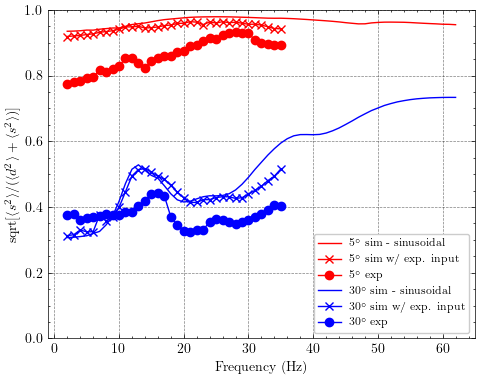

In [ ]:
plt.figure(figsize=(5,4))
plt.plot(jnp.arange(2, 63), dds_ratio_freqs5_sinusoidal, color='r', alpha=1., label='$5^{\circ}$ sim - sinusoidal')
plt.plot(jnp.arange(2, 63), dds_ratio_freqs30_sinusoidal, color='b', alpha=1., label='$30^{\circ}$ sim - sinusoidal')
plt.ylabel('sqrt[$ \langle s^2 \\rangle /( \langle d^2 \\rangle + \langle s^2 \\rangle)$]')
plt.xlabel('Frequency (Hz)')
plt.legend(fontsize=8)
plt.ylim([0, 1])
plt.tight_layout()

### Load and visualize dilation and shear data across frequencies for experiments, simulations with experimental input, and simulations with ideal harmonic input

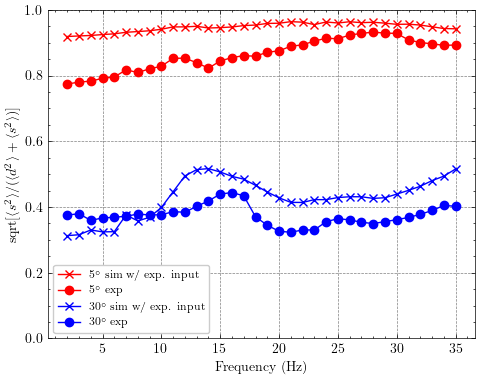

In [ ]:
dds_ratio_freqs5_loaded = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/dilation_shear_across_frequencies_5deg.pkl', allow_pickle=True)
dds_ratio_freqs30_loaded = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/exp_harmonic_input/dilation_shear_across_frequencies_30deg.pkl', allow_pickle=True)

dds_ratio_freqs5_sinusoidal_loaded = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/dilation_shear_across_frequencies_5deg.pkl', allow_pickle=True)
dds_ratio_freqs30_sinusoidal_loaded = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/harmonic_input_freq_dependence/dilation_shear_across_frequencies_30deg.pkl', allow_pickle=True)

dds_ratio_freqs5_exp_loaded = np.load(f'../../data/nonlinear_data/exp/dilation_shear_across_frequencies_5deg.pkl', allow_pickle=True)
dds_ratio_freqs30_exp_loaded = np.load(f'../../data/nonlinear_data/exp/dilation_shear_across_frequencies_30deg.pkl', allow_pickle=True)


frequencies = jnp.arange(2, 36)
plt.figure(figsize=(5,4))
plt.plot(jnp.arange(2, 63), dds_ratio_freqs5_sinusoidal_loaded, color='r', alpha=1., label='$5^{\circ}$ sim - sinusoidal')
plt.plot(frequencies, dds_ratio_freqs5_loaded, color='r', marker='x', label='$5^{\circ}$ sim w/ exp. input')
plt.plot(frequencies, dds_ratio_freqs5_exp_loaded, color='r', marker='o', label='$5^{\circ}$ exp')
plt.plot(jnp.arange(2, 63), dds_ratio_freqs30_sinusoidal_loaded, color='b', alpha=1., label='$30^{\circ}$ sim - sinusoidal')
plt.plot(frequencies, dds_ratio_freqs30_loaded, color='b', marker='x', label='$30^{\circ}$ sim w/ exp. input')
plt.plot(frequencies, dds_ratio_freqs30_exp_loaded, color='b', marker='o', label='$30^{\circ}$ exp')
# plt.ylabel('$ \langle d^2 \\rangle /( \langle d^2 \\rangle + \langle s^2 \\rangle)$')
plt.ylabel('sqrt[$ \langle s^2 \\rangle /( \langle d^2 \\rangle + \langle s^2 \\rangle)$]')
plt.xlabel('Frequency (Hz)')
plt.legend(fontsize=8)
plt.ylim([0, 1])
plt.tight_layout()

### Run forward simulation, generate, save, and analyze dilation and shear information as a function of initial angle and amplitude

In [ ]:
# Run simulations
run_and_save_data = False
excitation_freqs = jnp.array([24])
initial_angles = jnp.array([5, 10, 15, 20, 25, 30, 35, 40])*jnp.pi/180 # [rad]
amplitudes = jnp.array([1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14.])

if run_and_save_data:
    for excitation_freq in excitation_freqs:
        for initial_angle_ in initial_angles:
            print('initial angle = ', initial_angle_*180/jnp.pi)
            for amplitude in amplitudes:
                print('amplitude = ', amplitude)
                
                n_cycles_excitation = 10
                simulation_time = (n_cycles_excitation*2/excitation_freq)
                timepoints = jnp.arange(0, simulation_time+0.001, 0.001)
                input_data = n_periods_sine(timepoints, amplitude, 0.064, excitation_freq, n_cycles_excitation)

                use_contact = True
                clamped_corners = True
                if amplitude < 1:
                    atol = 1e-9
                else:
                    atol = 1e-4

                problem_validate_angle = ForwardProblem(
                    n1_blocks=n1_blocks,
                    n2_blocks=n2_blocks,
                    spacing=spacing,
                    bond_length=hinge_length,
                    initial_angle=initial_angle_,
                    k_stretch=k_stretch,
                    k_shear=k_shear,
                    k_rot=k_rot,
                    density=density,
                    damping=0*damping,
                    internal_damping=internal_damping,
                    damped_bonds_active=True,
                    simulation_time=simulation_time,
                    loaded_side=loaded_side,
                    n_excited_blocks=n_excited_blocks,
                    exp_driving_signal=True,
                    exp_driving_signal_data=input_data,
                    driving_angle=driving_angle,
                    use_contact=use_contact,
                    clamped_corners=clamped_corners,
                    atol=atol,
                )
                problem_validate_angle.setup()
                problem_validate_angle.solution_data = problem_validate_angle.solve()

                save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/amplitude_angle_dependence/{excitation_freq}Hz/initial_angle_{initial_angle_*180/jnp.pi:.1f}_{amplitude}mm_{n_cycles_excitation}periods_sine_solution_data.pkl', problem_validate_angle.solution_data)

In [ ]:
# Calculate dilation and shear values
if run_and_save_data:
    for excitation_freq in excitation_freqs:
        for initial_angle_ in initial_angles:
            for amplitude in amplitudes:
                print('initial angle = ', initial_angle_*180/jnp.pi)

                n_cycles_excitation = 10

                data_info_i = load_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/amplitude_angle_dependence/{excitation_freq}Hz/initial_angle_{initial_angle_*180/jnp.pi:.1f}_{amplitude}mm_{n_cycles_excitation}periods_sine_solution_data.pkl')
                data_info_i_fields = data_info_i.fields

                n_cycles = 10
                end_frame = int((2*n_cycles/excitation_freq)*1000)
                if end_frame > data_info_i.fields.shape[0]:
                    end_frame = data_info_i.fields.shape[0]

                time_steps = jnp.arange(end_frame)
                dilation_shear_dict = generate_SS_image_info_nonlinear_symmetric_UC_blocks(data_info_i_fields[:end_frame, 0, :, :], data_info_i.block_centroids, time_steps, geometry=problem.geometry)

                save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/amplitude_angle_dependence/{excitation_freq}Hz/dilation_shear/initial_angle_{initial_angle_*180/jnp.pi:.1f}_{amplitude}mm_{n_cycles_excitation}periods_sine_dilation_shear_data.pkl', dilation_shear_dict)


In [19]:
if run_and_save_data:
    n_cycles_excitation = 10
    ds_avgs = jnp.zeros([len(excitation_freqs), len(initial_angles), len(amplitudes)])

    for pp, excitation_freq in enumerate(excitation_freqs):
        for i, initial_angle_ in enumerate(initial_angles):
            for j, amplitude in enumerate(amplitudes):


                ds_dict = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/amplitude_angle_dependence/{excitation_freq}Hz/dilation_shear/initial_angle_{initial_angle_*180/jnp.pi:.1f}_{amplitude}mm_{n_cycles_excitation}periods_sine_dilation_shear_data.pkl', allow_pickle=True)

                # Get quantities out from dictionaries
                d = jnp.sqrt(ds_dict['d']**2)
                s_sq = ds_dict['s_sq']

                n_cycles = 10
                end_frame = int((n_cycles/excitation_freq)*1000)
                frames_to_analyze = jnp.array([65, end_frame+64])
                last_ten_cycles_frames = jnp.array([frames_to_analyze[0], end_frame+64])

                ##### average the dilation and shear values #####
                d_sq_avg = jnp.mean(d**2, axis=1) # (n_timepoints,)
                s_sq_avg = jnp.mean(s_sq, axis=1) # (n_timepoints,)

                ##### d^2 / (d^2 + s^2) #####
                dds_ratio_temp = jnp.sqrt(s_sq_avg / (d_sq_avg + s_sq_avg)) # (n_timepoints,)
                dds_ratio_freq = jnp.mean(dds_ratio_temp[last_ten_cycles_frames[0]:last_ten_cycles_frames[1]]) # (1,)

                ds_avgs = ds_avgs.at[pp, i, j].set(dds_ratio_freq)

    save_data(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/amplitude_angle_dependence/ds_avgs_across_frequencies_angles_amplitudes.pkl', ds_avgs)

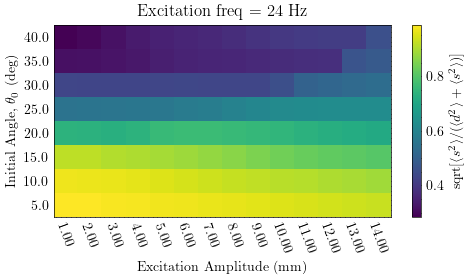

In [20]:
ds_avgs_loaded = np.load(f'../../data/nonlinear_data/internal_damping/k_stretch_20.59_k_shear_0.83_k_rot_1.68/amplitude_angle_dependence/ds_avgs_across_frequencies_angles_amplitudes.pkl', allow_pickle=True)

max_val = jnp.max(jnp.array([jnp.max(ds_avgs_loaded[0]), jnp.max(ds_avgs_loaded[1])]))
min_val = jnp.min(jnp.array([jnp.min(ds_avgs_loaded[0]), jnp.min(ds_avgs_loaded[1])]))
plt.figure(figsize=(5,3))
plt.pcolor(ds_avgs_loaded[0], vmax=max_val, vmin=min_val)
plt.title(f'Excitation freq = {excitation_freqs[0]} Hz')
plt.xlabel('Excitation Amplitude (mm)')
plt.xticks(jnp.arange(len(amplitudes))+0.5, array_to_string(amplitudes, 2), rotation=-70)#amplitudes)
plt.ylabel('Initial Angle, $\\theta_0$ (deg)')
plt.yticks(jnp.arange(len(initial_angles))+0.5, array_to_string(initial_angles*180/jnp.pi, 1))
plt.colorbar(label='sqrt[$\langle s^2 \\rangle / (\langle d^2 \\rangle + \langle s^2 \\rangle)$]')
plt.tight_layout()